# Regional Logistics Transfers – Delay Prediction

**Group #15**

The task is a binary classification problem: predict whether a transfer arrives **more than 30 minutes late** relative to its scheduled arrival time (`is_delayed`).

## Part 1: Exploration

## Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Consistent, readable plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
TARGET = "is_delayed"

DATA_DIR = Path(os.environ.get("DATA_DIR", "data"))
TRAIN_PATH = DATA_DIR / "regional_logistics_transfers_train.csv"
TEST_PATH = DATA_DIR / "regional_logistics_transfers_test.csv"

## Data Sanity & Initial Profiling

We load the training set and take a first look at its shape, data types, summary statistics, number of unique values per column and missing values. The goal is to understand what each column represents, spot irrelevant columns, and get an early sense of distributions and potential outliers.

In [2]:
# Load the training data.
print(f"Loading training data from: {TRAIN_PATH}")
df = pd.read_csv(TRAIN_PATH)
print("Shape (rows, columns):", df.shape)
df.head()

Loading training data from: data/regional_logistics_transfers_train.csv
Shape (rows, columns): (51056, 23)


,operation_date,day_of_week,scheduled_dispatch_time,expected_dispatch_delay_minutes,scheduled_arrival_time,source_facility,source_region,destination_facility,destination_region,logistics_provider,...,expected_weather_disruption_minutes,expected_network_congestion_delay_minutes,expected_inspection_delay_minutes,expected_previous_transfer_delay_minutes,internal_metric_a,internal_metric_b,internal_timestamp_a,internal_timestamp_b,internal_operational_score,is_delayed
0,2024-04-01,1,830,2.0,1217,FACILITY_298,REGION_005,FACILITY_091,REGION_006,UA,...,0.0,0.0,0.0,0,NaN,4.0,900.0,1202.0,52.542136,0
1,2024-04-01,1,1500,-7.0,1642,FACILITY_112,REGION_029,FACILITY_273,REGION_032,9E,...,0.0,0.0,0.0,0,14.0,4.0,1451.0,1616.0,58.169563,0
2,2024-04-01,1,1340,-3.0,1522,FACILITY_273,REGION_032,FACILITY_174,REGION_031,9E,...,0.0,0.0,0.0,0,16.0,5.0,1342.0,1537.0,57.702196,0
3,2024-04-01,1,1325,-11.0,1501,FACILITY_159,REGION_048,FACILITY_099,REGION_021,9E,...,NaN,NaN,0.0,0,14.0,6.0,1220.0,1427.0,51.548966,0
4,2024-04-01,1,1012,-5.0,1200,FACILITY_099,REGION_021,FACILITY_174,REGION_031,9E,...,0.0,0.0,0.0,0,23.0,NaN,1055.0,1202.0,61.802930,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51056 entries, 0 to 51055
Data columns (total 23 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   operation_date                             51056 non-null  object 
 1   day_of_week                                51056 non-null  int64  
 2   scheduled_dispatch_time                    51056 non-null  int64  
 3   expected_dispatch_delay_minutes            50435 non-null  float64
 4   scheduled_arrival_time                     51056 non-null  int64  
 5   source_facility                            51056 non-null  object 
 6   source_region                              51056 non-null  object 
 7   destination_facility                       51056 non-null  object 
 8   destination_region                         51056 non-null  object 
 9   logistics_provider                         51056 non-null  object 
 10  scheduled_travel_time_

In [4]:
# Summary statistics for the columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day_of_week,51056.0,3.976614,1.997433,1.000000,2.000000,4.000000,6.00000,7.000000
scheduled_dispatch_time,51056.0,1312.670538,390.114446,700.000000,951.000000,1317.000000,1650.00000,1959.000000
expected_dispatch_delay_minutes,50435.0,15.702786,58.350467,-22.000000,-5.000000,-1.000000,12.00000,2120.000000
scheduled_arrival_time,51056.0,1573.085396,422.308204,1.000000,1230.000000,1608.000000,1925.00000,2359.000000
scheduled_travel_time_minutes,51056.0,184.786607,85.959995,55.000000,122.000000,167.000000,221.00000,764.000000
route_distance_miles,51056.0,1181.731808,769.964405,92.000000,663.600000,1033.800000,1498.40000,14341.700000
expected_provider_delay_minutes,47480.0,5.132603,36.426832,0.000000,0.000000,0.000000,0.00000,2053.000000
expected_weather_disruption_minutes,45952.0,0.572380,12.246334,0.000000,0.000000,0.000000,0.00000,1052.000000
expected_network_congestion_delay_minutes,46966.0,4.295192,22.486952,0.000000,0.000000,0.000000,0.00000,1080.000000
expected_inspection_delay_minutes,44933.0,0.022166,0.997570,0.000000,0.000000,0.000000,0.00000,94.000000


In [5]:
# Number of unique values per column
# Helps to explore the data and understand the different values each feature can take.
df.nunique().sort_values()

is_delayed                                       2
operation_date                                   7
day_of_week                                      7
logistics_provider                              28
expected_inspection_delay_minutes               33
source_facility                                 40
destination_facility                            40
source_region                                   47
destination_region                              48
internal_metric_b                               89
internal_metric_a                              136
expected_weather_disruption_minutes            147
expected_network_congestion_delay_minutes      294
expected_provider_delay_minutes                320
expected_previous_transfer_delay_minutes       371
scheduled_travel_time_minutes                  398
expected_dispatch_delay_minutes                517
scheduled_dispatch_time                        780
scheduled_arrival_time                        1020
route_distance_miles           

In [6]:
# Missing values per feature, as a count and as a percentage of all rows
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_pct": (df.isnull().mean() * 100).round(2),
})
missing = missing[missing["missing_count"] > 0].sort_values("missing_count", ascending=False)
missing

,missing_count,missing_pct
internal_metric_a,8320,16.30
expected_inspection_delay_minutes,6123,11.99
internal_metric_b,5782,11.32
expected_weather_disruption_minutes,5104,10.00
expected_network_congestion_delay_minutes,4090,8.01
expected_provider_delay_minutes,3576,7.00
internal_timestamp_b,680,1.33
internal_timestamp_a,669,1.31
expected_dispatch_delay_minutes,621,1.22


In [7]:
# Group the columns by role, this is reused throughout the exploration.
delay_cols = [
    "expected_dispatch_delay_minutes",
    "expected_provider_delay_minutes",
    "expected_weather_disruption_minutes",
    "expected_network_congestion_delay_minutes",
    "expected_inspection_delay_minutes",
    "expected_previous_transfer_delay_minutes",
]
route_cols = ["scheduled_travel_time_minutes", "route_distance_miles"]
anon_cols = [
    "internal_metric_a",
    "internal_metric_b",
    "internal_timestamp_a",
    "internal_timestamp_b",
    "internal_operational_score",
]
categorical_cols = [
    "source_region",
    "destination_region",
    "source_facility",
    "destination_facility",
    "logistics_provider",
    "day_of_week",
]
print("Delay columns:", len(delay_cols), "| Route:", len(route_cols), "| Anonymous:", len(anon_cols))

Delay columns: 6 | Route: 2 | Anonymous: 5


## Univariate Distribution Analysis

We look at one variable at a time: the balance of the target, the distribution of the continuous features (route, delays, anonymous metrics) and the frequency of the main categorical fields. This tells us which features are roughly symmetric, which are heavy-tailed, and where outliers live.

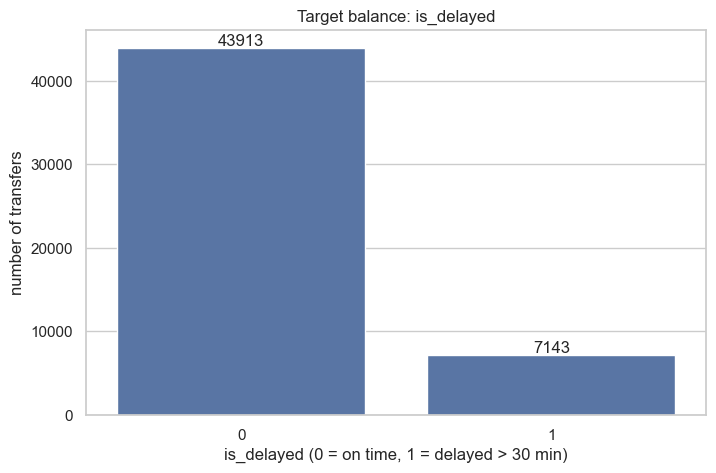

is_delayed
0    0.8601
1    0.1399
Name: proportion, dtype: float64


In [8]:
# Target balance
ax = sns.countplot(data=df, x=TARGET)
ax.set_title("Target balance: is_delayed")
ax.set_xlabel("is_delayed (0 = on time, 1 = delayed > 30 min)")
ax.set_ylabel("number of transfers")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

print(df[TARGET].value_counts(normalize=True).round(4))

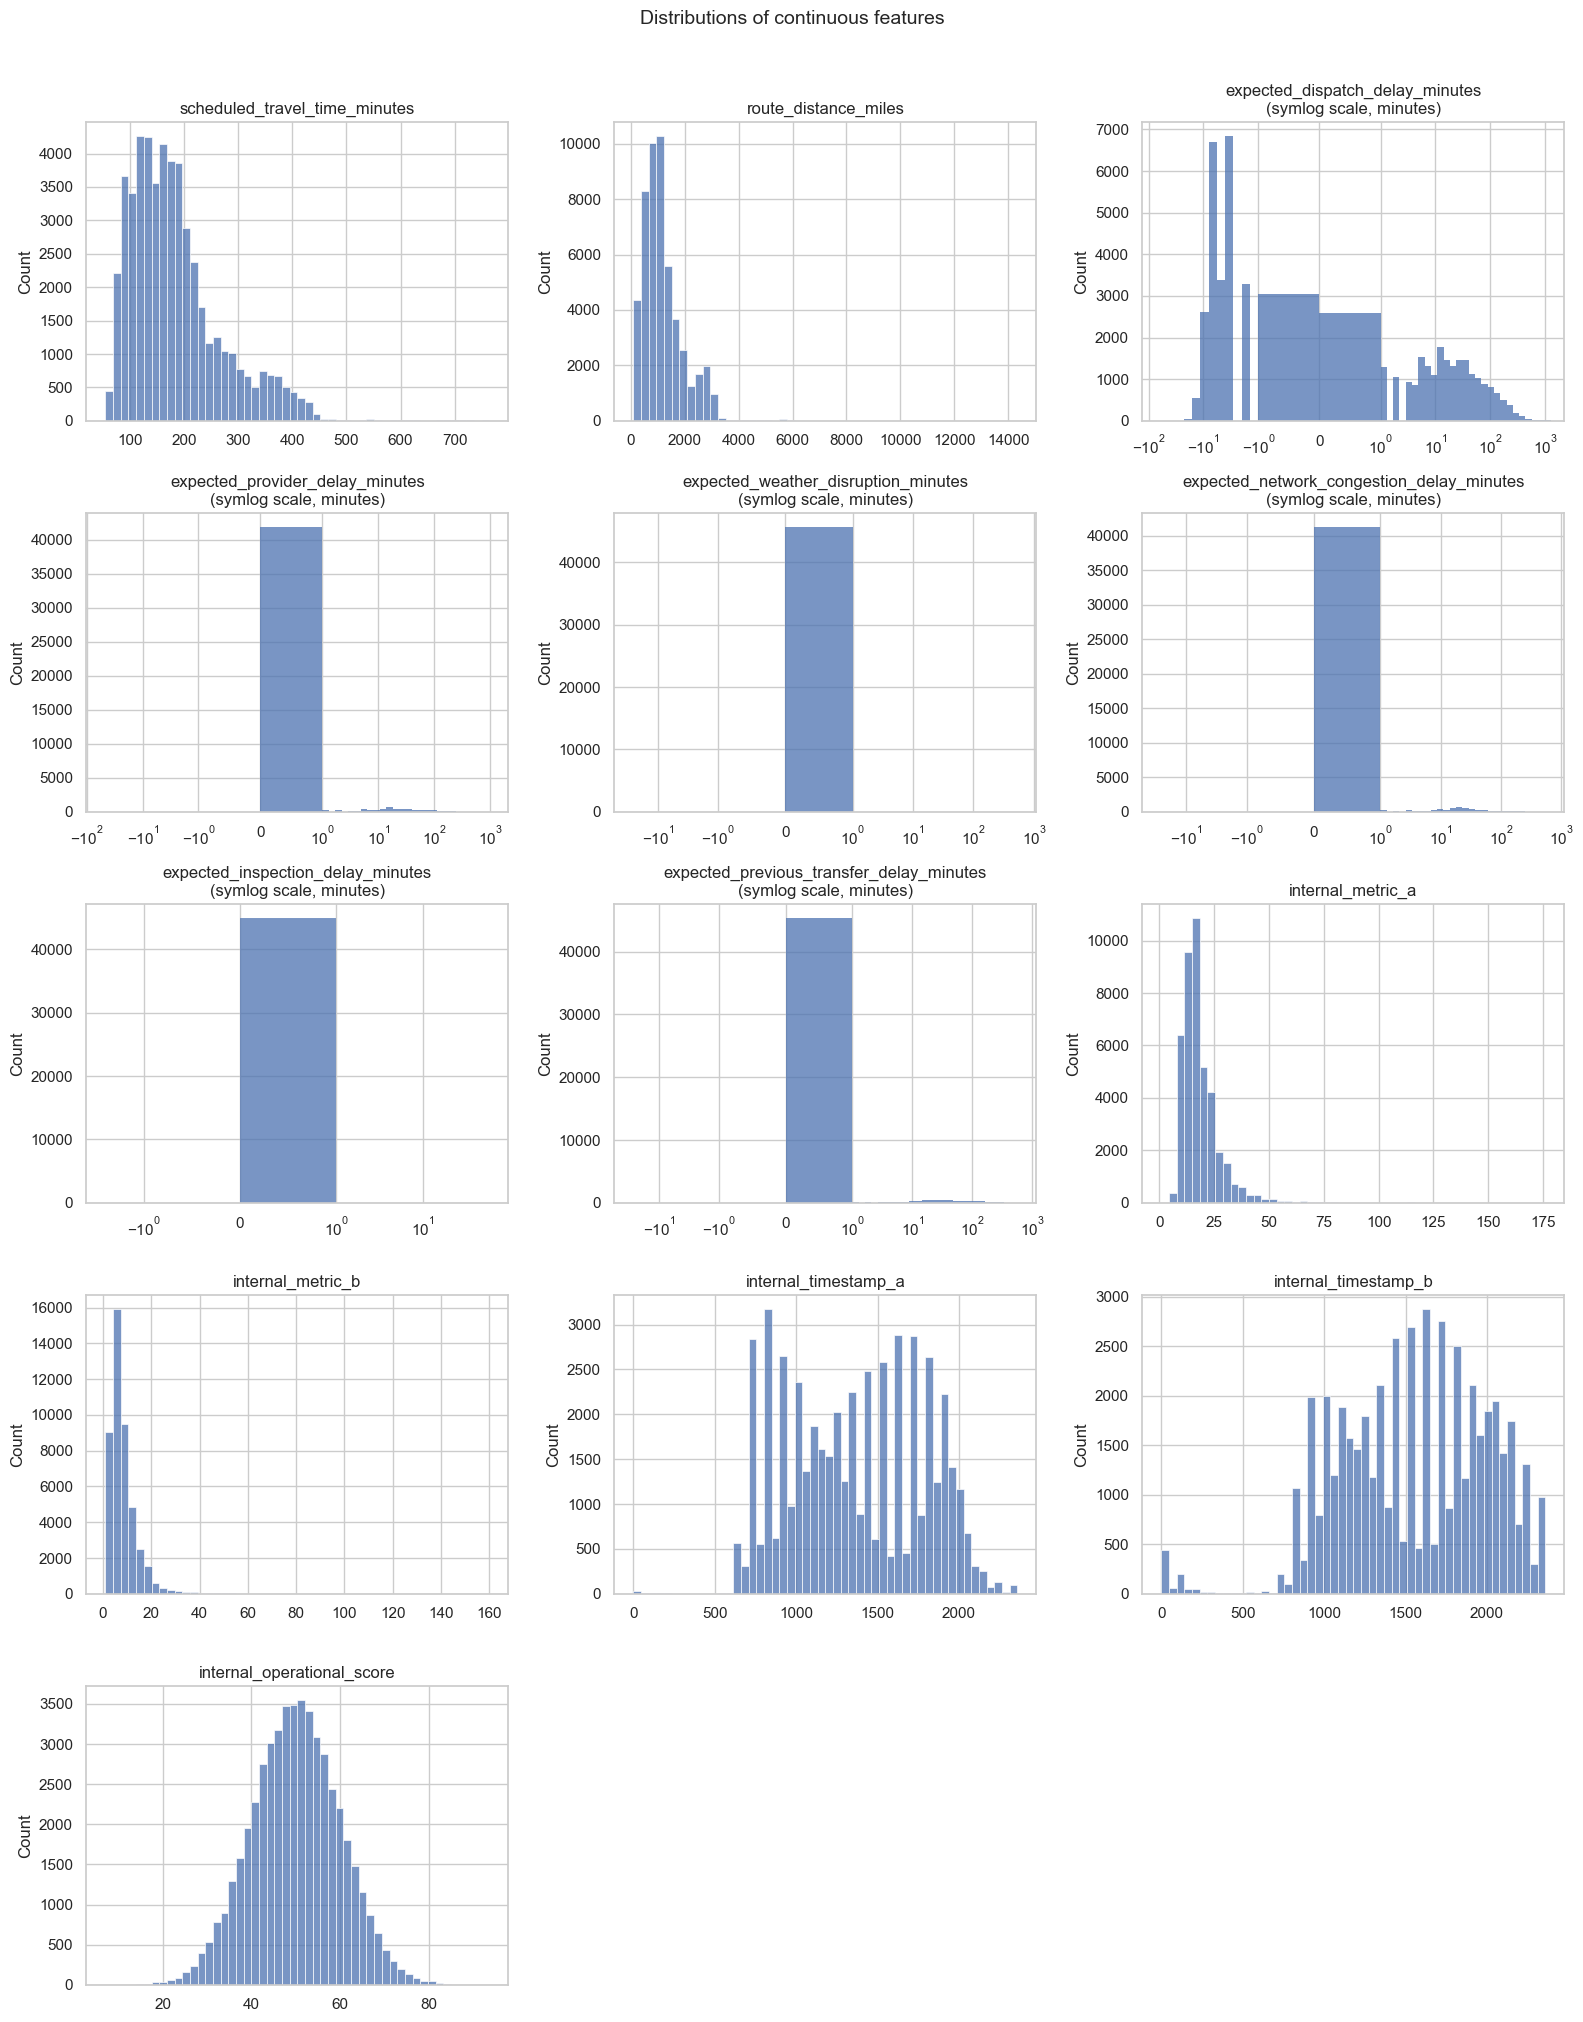

In [9]:
# GOOVER
# Histograms of the continuous features
# Expected-delay columns are zero-inflated and right-skewed -> symlog x-scale.
# Symlog is linear around 0 (|x| < linthresh) and logarithmic in both tails,
# so it keeps the raw minute values, preserves the negative early-dispatch
# values (e.g. expected_dispatch_delay_minutes goes down to ~-22) and still
# compresses the heavy right tail.
continuous_cols = route_cols + delay_cols + anon_cols

n_cols = 3
n_rows = int(np.ceil(len(continuous_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, continuous_cols):
    data = df[col].dropna()
    if col in delay_cols:
        # Symlog-spaced bin edges so the histogram is not dominated by the
        # zero spike: linear bins inside [-linthresh, linthresh], log-spaced
        # bins out to each tail. Plotted on a matching symlog x-axis.
        linthresh = 1.0
        pos_max = data.max()
        neg_min = data.min()
        edges = [0.0, linthresh]
        if pos_max > linthresh:
            edges += list(np.logspace(np.log10(linthresh), np.log10(pos_max), 30))
        if neg_min < 0:
            neg_edges = list(-np.logspace(np.log10(linthresh),
                                          np.log10(max(-neg_min, linthresh) + 1), 10))
            edges += [-linthresh] + neg_edges
        bins = np.unique(np.array(edges))
        sns.histplot(data, bins=bins, ax=ax)
        ax.set_xscale("symlog", linthresh=linthresh)
        ax.set_title(f"{col}\n(symlog scale, minutes)")
    else:
        sns.histplot(data, bins=50, ax=ax)
        ax.set_title(col)
    ax.set_xlabel("")

# Hide any unused subplot
for ax in axes[len(continuous_cols):]:
    ax.set_visible(False)

fig.suptitle("Distributions of continuous features", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()


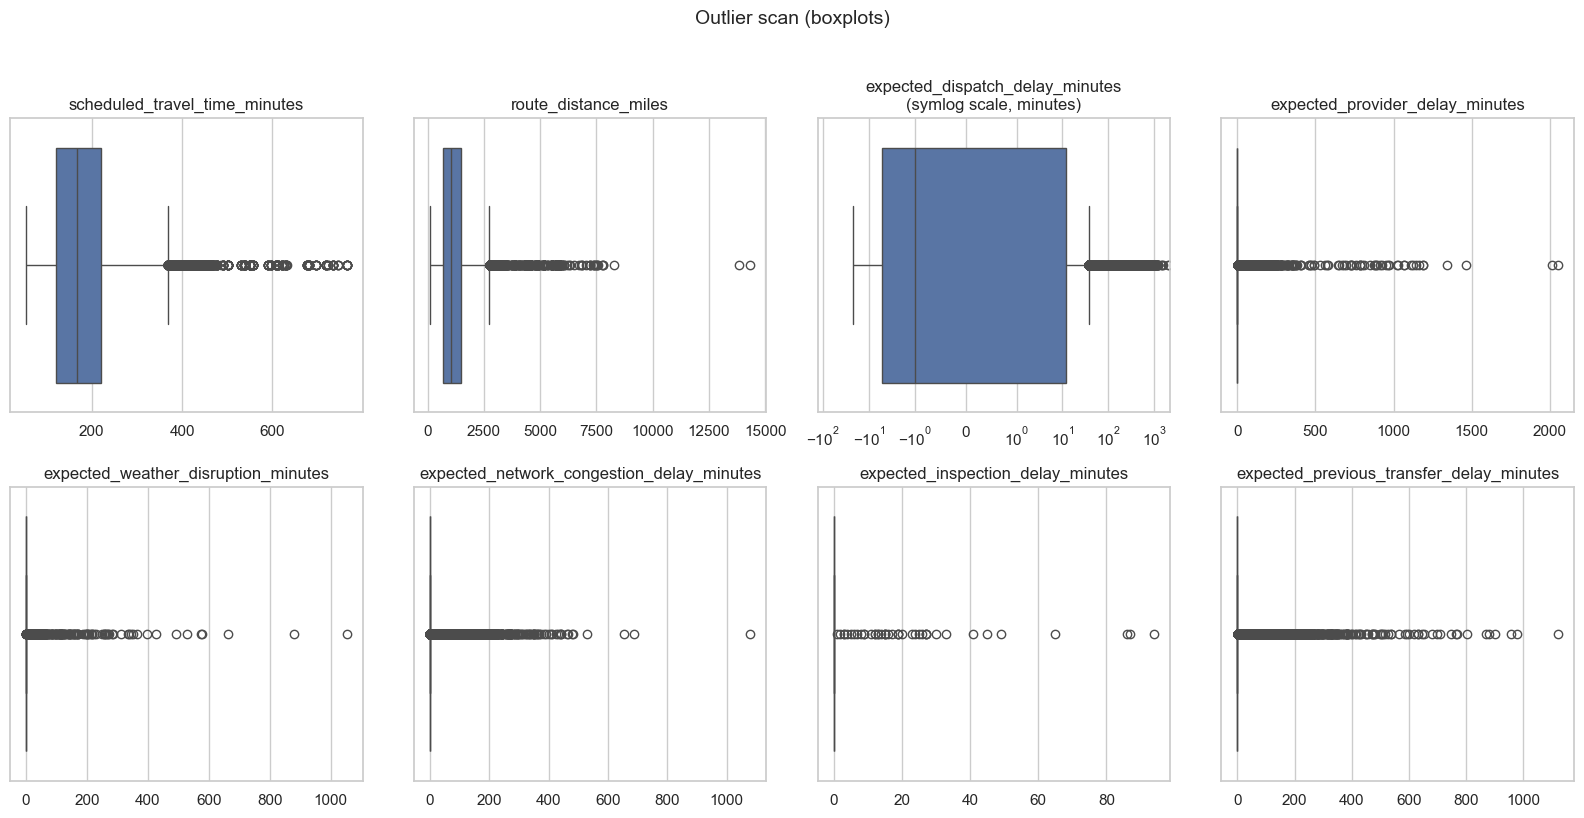

In [10]:
# Boxplots to make the outliers in the route and delay features explicit and proven
box_cols = route_cols + delay_cols

n_cols = 4
n_rows = int(np.ceil(len(box_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for ax, col in zip(axes, box_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    if col == "expected_dispatch_delay_minutes":
        ax.set_xscale("symlog", linthresh=1)
        ax.set_title(f"{col}\n(symlog scale, minutes)")

for ax in axes[len(box_cols):]:
    ax.set_visible(False)

fig.suptitle("Outlier scan (boxplots)", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()


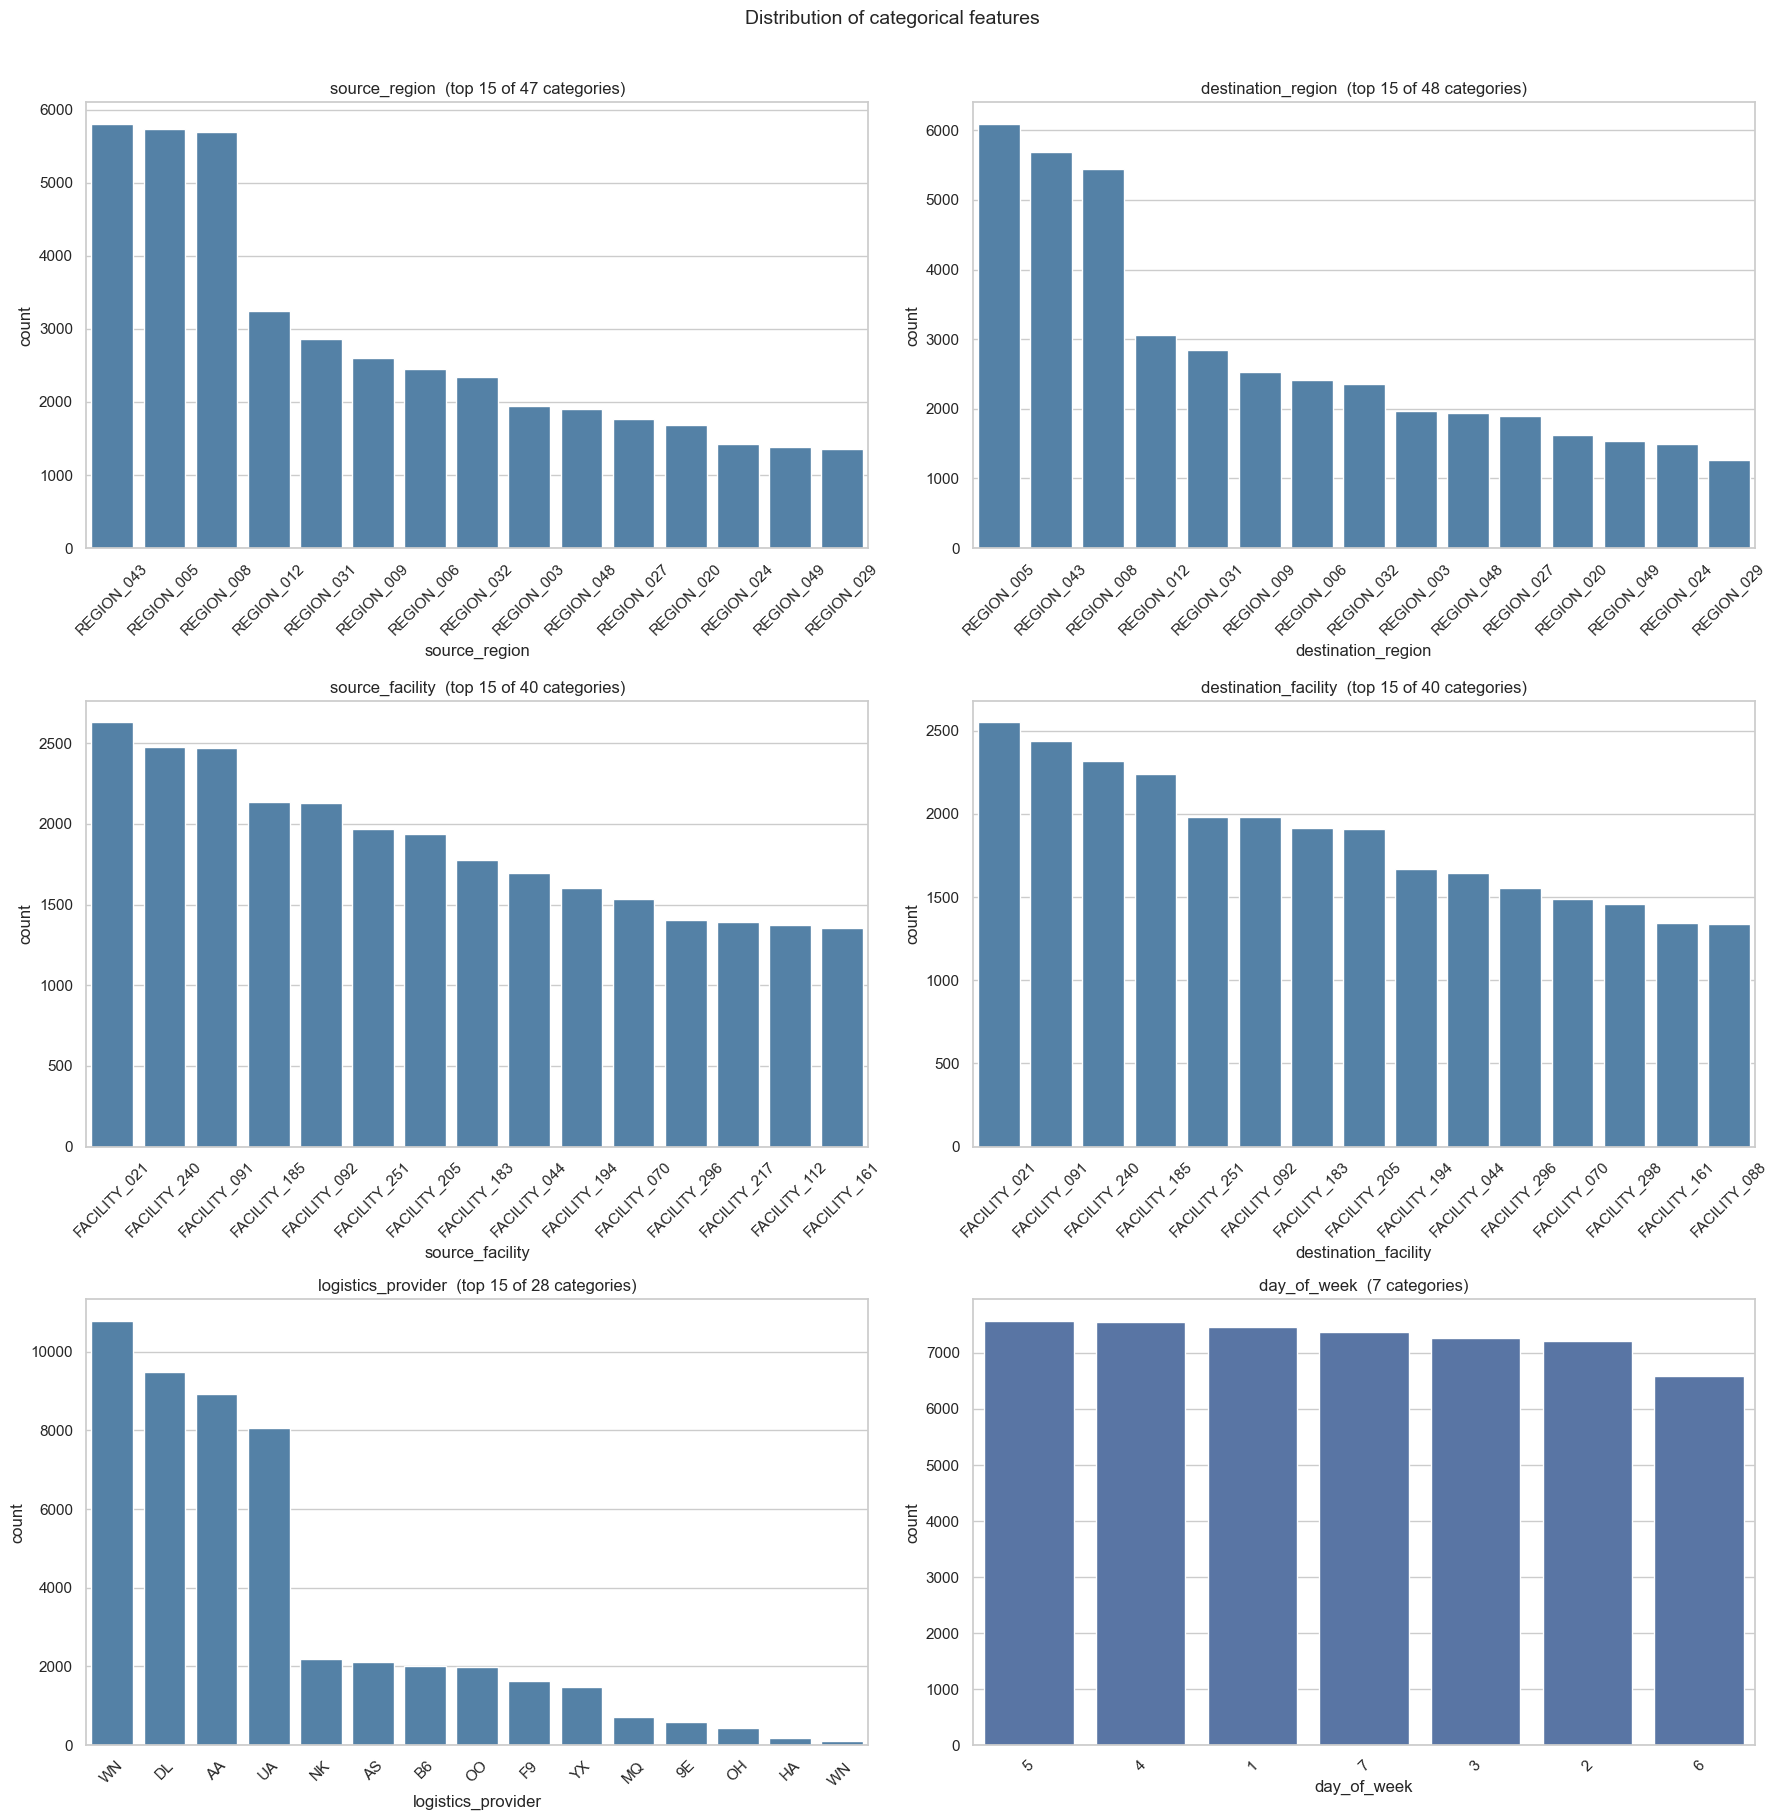

In [11]:
# Distribution of all categorical features
# Low-cardinality features (logistics_provider, day_of_week): full countplot.
# High-cardinality features (regions, facilities): top 15 categories by count.
# All plots share the same orientation: count on y-axis, category value on x-axis.

TOP_N = 15

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts()
    n_unique = len(counts)

    if n_unique <= 20:
        # Show all categories
        sns.countplot(data=df, x=col, order=counts.index, ax=ax)
        ax.set_title(f"{col}  ({n_unique} categories)")
    else:
        # Show only top N by frequency
        top = counts.head(TOP_N)
        sns.barplot(x=top.index, y=top.values, color="steelblue", ax=ax)
        ax.set_title(f"{col}  (top {TOP_N} of {n_unique} categories)")
        ax.set_ylabel("count")

    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel(col)

fig.suptitle("Distribution of categorical features", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()


### Conclusions

- **Target imbalance.** Confirmed visually: 43,913 on-time vs. 7,143 delayed (~14% positive class). Models and evaluation should account for this (AUC, class weights / resampling).
- **Roughly normal feature.** `internal_operational_score` is clearly bell-shaped around 50 with std ~10 – the only feature that looks approximately Gaussian.
- **Heavy-tailed / skewed features.** `route_distance_miles`, `scheduled_travel_time_minutes`, `internal_metric_a` and `internal_metric_b` are right-skewed with a long tail (a Chi-square-like shape). The six expected-delay columns are **zero-inflated**: the vast majority of values are exactly 0 with a small fraction of very large delays. These will likely benefit from a log/robust transform and outlier handling later.
- **Anonymous timestamps.** `internal_timestamp_a` and `internal_timestamp_b` span 0–2359 and are concentrated in daytime hours – they behave like `HHMM` clock times rather than opaque metrics, with a small spike near 0 (likely midnight or a placeholder).
- **Outliers.** The boxplots show many extreme high values in every delay column and in `route_distance_miles` (a few routes above 8,000–14,000 miles). We will decide how to treat these in the preprocessing phase rather than discard them now.
- **Categoricals.** Transfers are spread fairly evenly across the 7 days of the week (slightly fewer on day 6). The provider field is dominated by four carriers (WN, DL, AA, UA). **Data-quality issue found:** `logistics_provider` has trailing-whitespace duplicates (e.g. `'9E '` vs `'9E'`), which split 14 real codes into 28 categories. This must be stripped/normalised in preprocessing.

## Bivariate & Multivariate Analysis

In this phase we answer the assignment's exploration questions one by one. For each question we compute the relevant statistic, plot it, and write the conclusion in a Markdown cell directly below.

Because we will repeatedly group categorical text fields, we first apply a **minimal text cleanup** (strip surrounding whitespace) so that the trailing-space duplicates found above do not split groups. This is the only cleaning done in the exploration phase; full preprocessing happens in Part 2.

In [12]:
# Minimal text cleanup so grouping is not distorted by trailing whitespace
text_cols = df.select_dtypes(include="object").columns
df[text_cols] = df[text_cols].apply(lambda s: s.str.strip())

print("logistics_provider categories after cleanup:", df["logistics_provider"].nunique())

logistics_provider categories after cleanup: 15


### GOOVER Q1: Differences in delay level between regions and between logistics providers

We measure the **delay rate** (the mean of `is_delayed`) for each logistics provider and for each source / destination region. The overall delay rate (~14%) is the baseline; we look for groups that deviate strongly from it. We only show regions with a reasonable number of transfers so the rates are not driven by tiny samples.

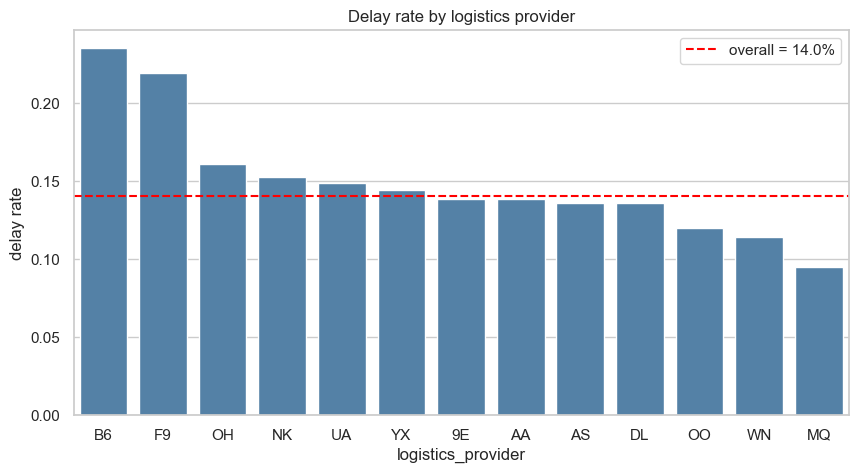

,delay_rate,n
logistics_provider,,
B6,0.235,2015
F9,0.219,1635
OH,0.160,424
NK,0.152,2213
UA,0.148,8145
YX,0.144,1484
9E,0.139,599
AA,0.138,9004
AS,0.136,2138


In [13]:
overall_rate = df[TARGET].mean()


def delay_rate_by(col, min_count=200):
    """Mean delay rate and transfer count per category of `col`, filtered by a
    minimum number of transfers so rates are not driven by tiny groups."""
    g = df.groupby(col)[TARGET].agg(delay_rate="mean", n="count")
    return g[g["n"] >= min_count].sort_values("delay_rate", ascending=False)


# Delay rate per logistics provider
provider_rate = delay_rate_by("logistics_provider", min_count=200)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=provider_rate.reset_index(), x="logistics_provider", y="delay_rate",
                 order=provider_rate.index, color="steelblue")
ax.axhline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
ax.set_title("Delay rate by logistics provider")
ax.set_ylabel("delay rate")
ax.legend()
plt.show()

provider_rate.round(3)

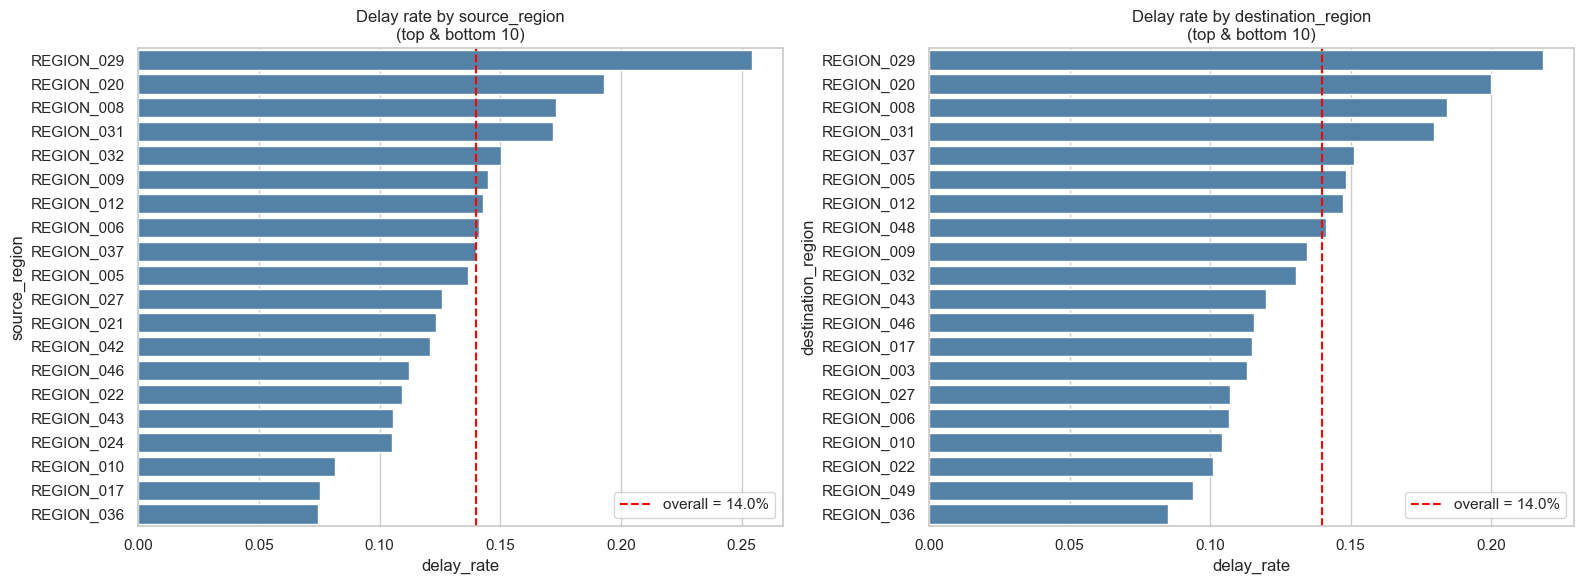

Source region delay rate – spread:min=7.5%, max=25.4%
Dest region delfdsfdsfsafdsa– spread:min=8.5%, max=21.9%


In [14]:
# Delay rate per source and destination region (top and bottom 10 by rate)
source_rate = delay_rate_by("source_region", min_count=200)
dest_rate = delay_rate_by("destination_region", min_count=200)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (rate, name) in zip(axes, [(source_rate, "source_region"), (dest_rate, "destination_region")]):
    extremes = pd.concat([rate.head(10), rate.tail(10)])
    sns.barplot(data=extremes.reset_index(), y=name, x="delay_rate", color="steelblue", ax=ax)
    ax.axvline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
    ax.set_title(f"Delay rate by {name}\n(top & bottom 10)")
    ax.legend()

fig.tight_layout()
plt.show()

print("Source region delay rate – spread:"
      f"min={source_rate['delay_rate'].min():.1%}, max={source_rate['delay_rate'].max():.1%}")
print("Dest region delfdsfdsfsafdsa– spread:"
      f"min={dest_rate['delay_rate'].min():.1%}, max={dest_rate['delay_rate'].max():.1%}")

### Answer 1

**Yes – there are clear differences both between providers and between regions.**

- **Providers:** delay rate ranges from ~9.4% (`MQ`) to ~23.5% (`B6`), against an overall 14%. `B6` and `F9` stand out as roughly **1.5–1.7× the average** delay rate, while large carriers such as `WN`, `DL` and `AA` sit at or slightly below average. The provider therefore carries real signal.
- **Regions:** the source region delay rate spans **7.5%–25.4%** and the destination region **8.5%–21.9%**. `REGION_029` is the worst on both ends (highest as a source *and* as a destination), while `REGION_036` is among the lowest on both. The consistency across source/destination suggests some regions are genuinely congestion-prone.

These differences are large relative to the 14% baseline, so `logistics_provider` and the region fields look like useful predictors and are worth encoding in the modelling phase.

### Q2 – Do certain departure hours have a higher probability of delay?

`scheduled_dispatch_time` is stored as an integer in `HHMM` format, so the hour is the value divided by 100. We extract the dispatch hour and compute the delay rate per hour across the day.

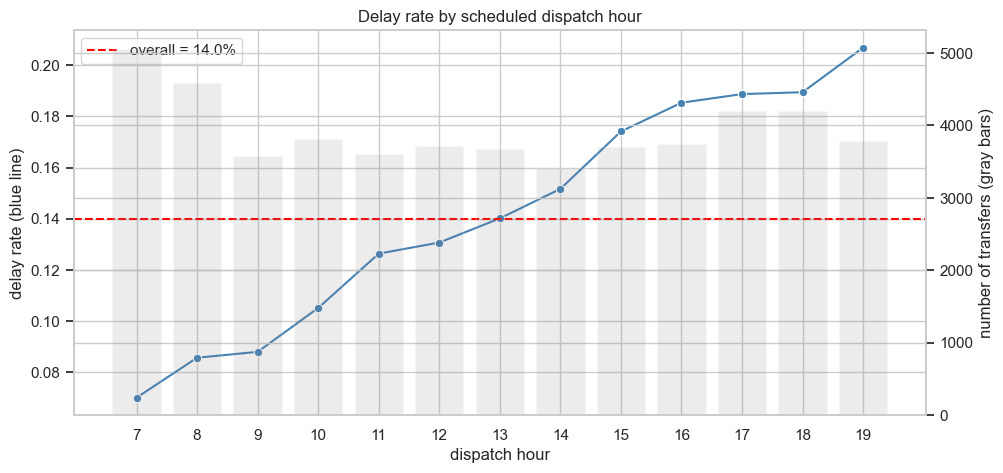

,delay_rate,n
dispatch_hour,,
7,0.070,5060
8,0.086,4583
9,0.088,3578
10,0.105,3813
11,0.126,3608
12,0.131,3718
13,0.140,3675
14,0.152,3409
15,0.174,3694


In [15]:
# Extract the dispatch hour from the HHMM integer and compute the delay rate per hour
df["dispatch_hour"] = df["scheduled_dispatch_time"] // 100

hourly = df.groupby("dispatch_hour")[TARGET].agg(delay_rate="mean", n="count")

fig, ax1 = plt.subplots(figsize=(11, 5))
sns.lineplot(data=hourly.reset_index(), x="dispatch_hour", y="delay_rate",
             marker="o", ax=ax1, color="steelblue")
ax1.axhline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
ax1.set_title("Delay rate by scheduled dispatch hour")
ax1.set_xlabel("dispatch hour")
ax1.set_ylabel("delay rate (blue line)")
ax1.set_xticks(hourly.index)
ax1.legend(loc="upper left")

# Number of transfers per hour for context
ax2 = ax1.twinx()
ax2.bar(hourly.index, hourly["n"], alpha=0.15, color="gray")
ax2.set_ylabel("number of transfers (gray bars)")
plt.show()

hourly.round(3)

### Answer 2

**Yes – the departure hour has a strong, almost monotonic effect.** All transfers are dispatched between 07:00 and 19:00. The delay rate rises steadily through the day: from only **~7%** for 07:00 departures to **~21%** for 19:00 departures – roughly a **3× difference**. The bars confirm that every hour has thousands of transfers, so the trend is not a small-sample artefact.

This matches the intuition that delays accumulate during the day (a transfer leaving late in the day is more exposed to earlier congestion and knock-on delays). `dispatch_hour` is clearly a valuable engineered feature for the model.

### Q3 – Relationship between departure delay and arrival delay

The dataset's arrival-delay information is the target itself: `is_delayed` marks transfers that arrived more than 30 minutes late. The departure-delay signal is `expected_dispatch_delay_minutes` (negative = dispatched early). We therefore study how the **departure delay** relates to the **probability of a significant arrival delay** (`is_delayed = 1`).

We use a boxplot of the departure delay split by the target, and a conditional-probability table where we bin the departure delay into ranges.

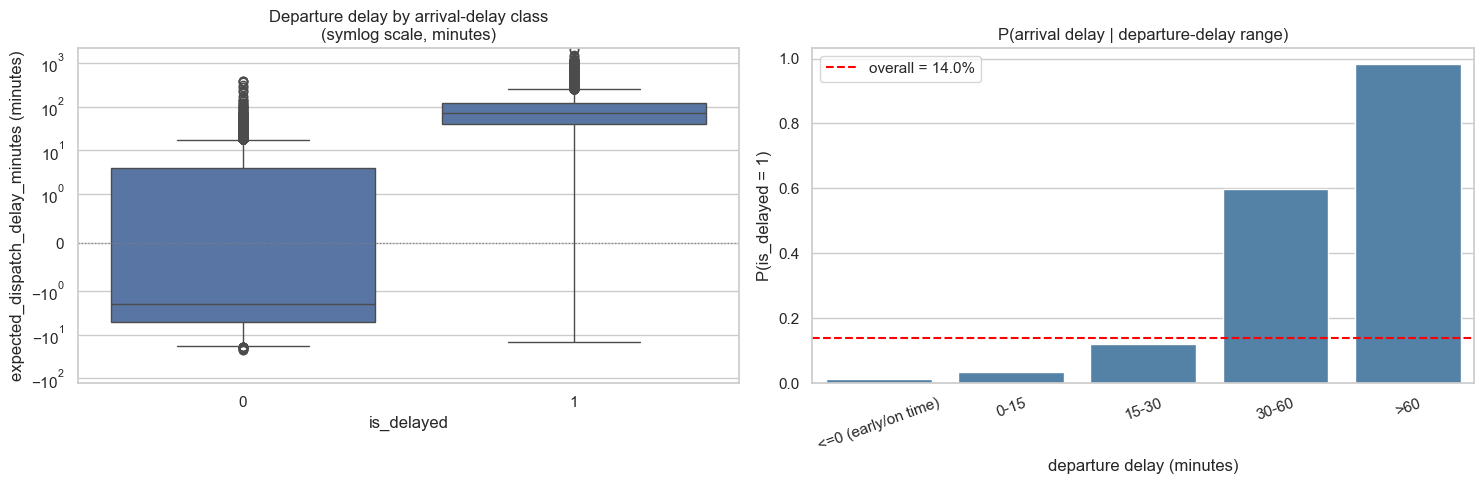

,p_arrival_delay,n
dispatch_delay_bin,,
<=0 (early/on time),0.012,29000
0-15,0.034,10280
15-30,0.121,3844
30-60,0.599,3155
>60,0.984,4156


In [16]:

# Departure delay distribution split by the arrival-delay target.
# Symlog scale: linear around 0 (|x| < 1 min) and logarithmic in both tails.
# This preserves negative values (early dispatch) and handles the heavy right tail
# without clipping or transforming the raw minute values.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=df, x=TARGET, y="expected_dispatch_delay_minutes", ax=axes[0])
axes[0].set_yscale("symlog", linthresh=1)
axes[0].axhline(0, color="gray", linestyle=":", linewidth=0.9)
axes[0].set_title("Departure delay by arrival-delay class\n(symlog scale, minutes)")
axes[0].set_xlabel("is_delayed")
axes[0].set_ylabel("expected_dispatch_delay_minutes (minutes)")

# Conditional probability of a significant arrival delay given a departure-delay range
bins = [-np.inf, 0, 15, 30, 60, np.inf]
labels = ["<=0 (early/on time)", "0-15", "15-30", "30-60", ">60"]
df["dispatch_delay_bin"] = pd.cut(df["expected_dispatch_delay_minutes"], bins=bins, labels=labels)

cond_prob = df.groupby("dispatch_delay_bin", observed=True)[TARGET].agg(
    p_arrival_delay="mean", n="count")

sns.barplot(data=cond_prob.reset_index(), x="dispatch_delay_bin", y="p_arrival_delay",
            color="steelblue", ax=axes[1])
axes[1].axhline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
axes[1].set_title("P(arrival delay | departure-delay range)")
axes[1].set_xlabel("departure delay (minutes)")
axes[1].set_ylabel("P(is_delayed = 1)")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

fig.tight_layout()
plt.show()

cond_prob.round(3)


### Answer 3

**Yes – there is a very strong relationship, and departure delay is the single most informative signal we have seen so far.**

- The boxplot shows that on-time transfers (`is_delayed = 0`) cluster around a *negative* departure delay (median ≈ −2 min, i.e. they leave slightly early), whereas delayed transfers have a much higher departure delay (median ≈ 70 min).
- The conditional-probability table makes the propagation explicit:
  - departure ≤ 0 min → only **1.2%** arrive significantly late,
  - 15–30 min → **12%**,
  - 30–60 min → **60%**,
  - \> 60 min → **98%**.

So a departure delay does not guarantee a late arrival until it grows past ~30 minutes, after which the probability of a significant arrival delay rises sharply. This makes intuitive sense (some of the departure delay can be absorbed by slack in the schedule, but large departure delays cannot be recovered). `expected_dispatch_delay_minutes` should be a top predictor.

### GOOVER Q4: Does the planned route distance affect the delay level?

We bin `route_distance_miles` into quantile groups (so each bin holds a similar number of transfers) and compute the delay rate per bin. Quantile binning is robust to the heavy right tail we saw earlier. We add a logistic trend line for the continuous view.

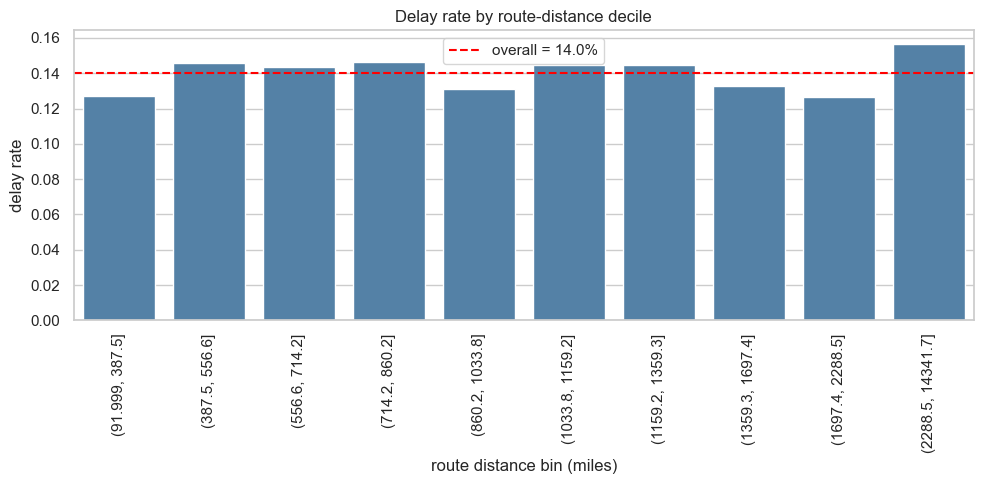

Pearson correlation (route_distance_miles, is_delayed): 0.006


,delay_rate,n
distance_bin,,
"(91.999, 387.5]",0.127,5148
"(387.5, 556.6]",0.146,5094
"(556.6, 714.2]",0.144,5134
"(714.2, 860.2]",0.146,5059
"(860.2, 1033.8]",0.131,5112
"(1033.8, 1159.2]",0.145,5101
"(1159.2, 1359.3]",0.144,5267
"(1359.3, 1697.4]",0.133,4977
"(1697.4, 2288.5]",0.126,5088


In [17]:
# Quantile bins of route distance -> delay rate per bin
df["distance_bin"] = pd.qcut(df["route_distance_miles"], q=10)
dist_rate = df.groupby("distance_bin", observed=True)[TARGET].agg(delay_rate="mean", n="count")

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(data=dist_rate.reset_index(), x="distance_bin", y="delay_rate",
            color="steelblue", ax=ax)
ax.axhline(overall_rate, color="red", linestyle="--", label=f"overall = {overall_rate:.1%}")
ax.set_title("Delay rate by route-distance decile")
ax.set_xlabel("route distance bin (miles)")
ax.set_ylabel("delay rate")
ax.tick_params(axis="x", rotation=90)
ax.legend()

fig.tight_layout()
plt.show()

# Correlation between raw distance and the target
corr_dist = df["route_distance_miles"].corr(df[TARGET])
print(f"Pearson correlation (route_distance_miles, is_delayed): {corr_dist:.3f}")
dist_rate.round(3)


### Answer 4

**No – the planned route distance has essentially no effect on the delay level.** Across all ten distance deciles the delay rate stays in a narrow **~12.6%–15.6%** band around the 14% baseline, with no monotonic trend. The Pearson correlation between `route_distance_miles` and `is_delayed` is only **0.006**, and the logistic trend line is almost flat. The longest-distance decile is marginally higher (15.6%), but the difference is small compared with the effects of provider, region, departure hour and departure delay.

Conclusion: distance on its own is a weak predictor. It may still contribute in interaction with other features, so we will not drop it outright, but we should not expect much from it.

### Q5 – Strong correlations between the different delay types?

We compute a correlation matrix over the six expected-delay columns plus the target. Because these columns are heavy-tailed and zero-inflated, **Spearman** (rank) correlation is more appropriate than Pearson, so we show Spearman and add Pearson for reference.

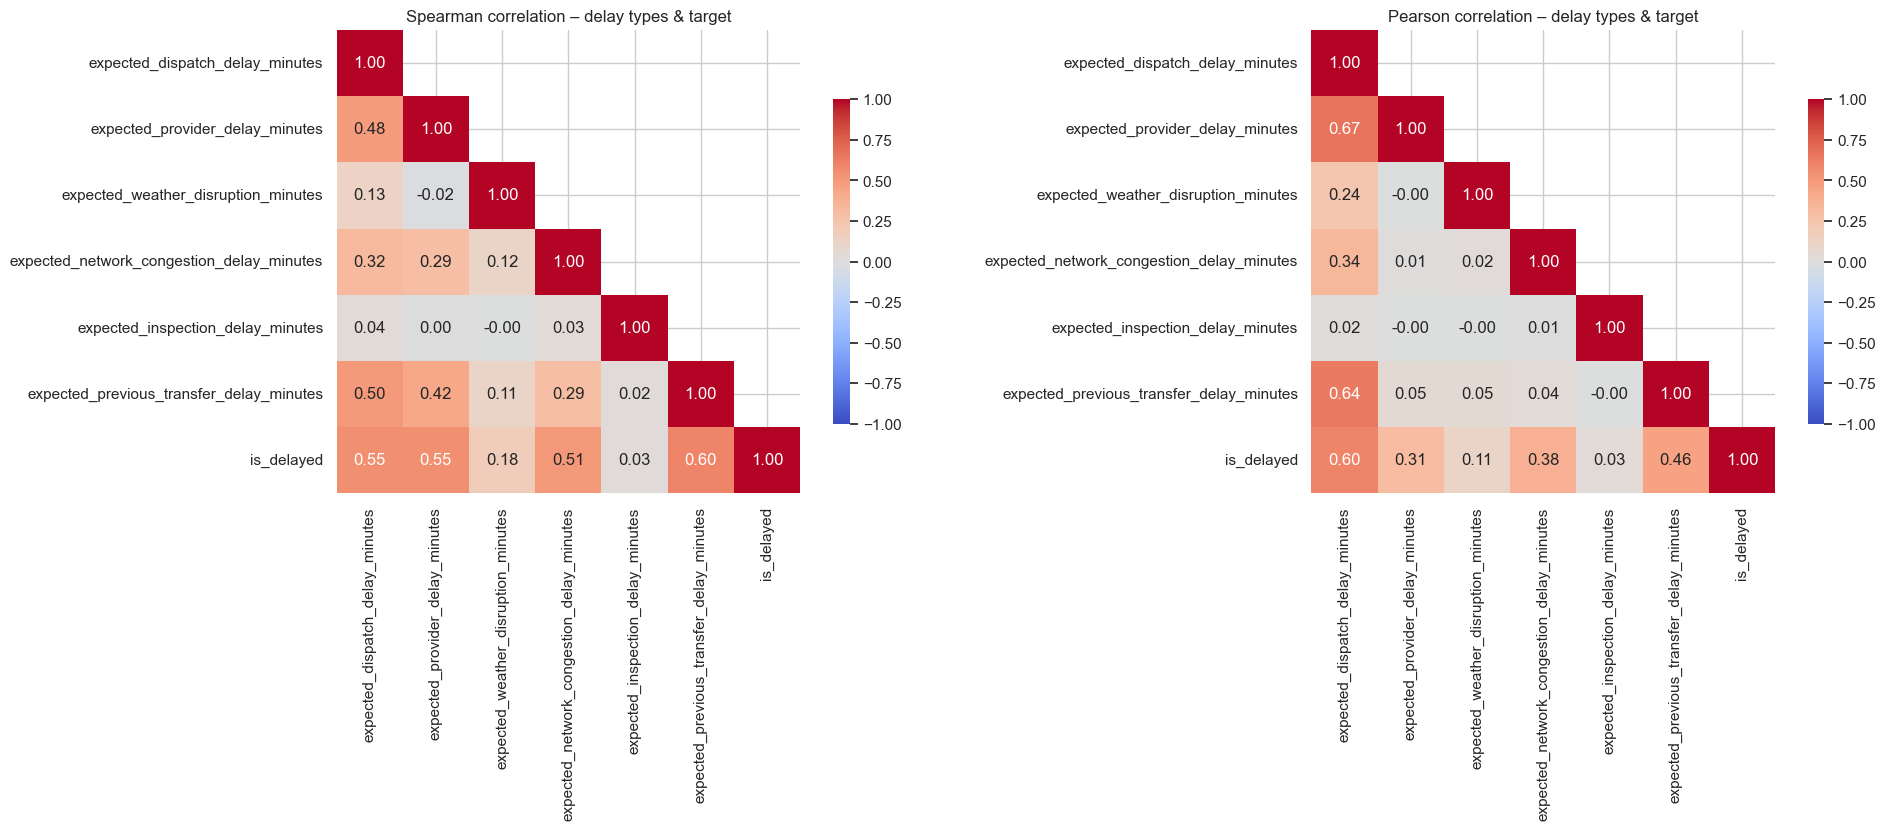

In [18]:
# Correlation between the delay types and the target (Spearman, with Pearson for reference)
corr_cols = delay_cols + [TARGET]

spearman_corr = df[corr_cols].corr(method="spearman")
pearson_corr = df[corr_cols].corr(method="pearson")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
for ax, (corr, name) in zip(axes, [(spearman_corr, "Spearman"), (pearson_corr, "Pearson")]):
    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
                vmin=-1, vmax=1, square=True, cbar_kws={"shrink": 0.7}, ax=ax)
    ax.set_title(f"{name} correlation – delay types & target")

fig.tight_layout()
plt.show()

### Answer 5

**There are moderate – but not extreme – correlations between the delay types, and several of them correlate well with the target.**

- **With the target (Spearman):** `expected_previous_transfer_delay_minutes` (0.60), `expected_dispatch_delay_minutes` (0.55), `expected_provider_delay_minutes` (0.55) and `expected_network_congestion_delay_minutes` (0.51) are the strongest. `expected_weather_disruption_minutes` (0.18) is weak and `expected_inspection_delay_minutes` (0.03) is essentially unrelated.
- **Between delay types:** the highest pairings are dispatch ↔ previous-transfer (0.50), dispatch ↔ provider (0.48) and provider ↔ previous-transfer (0.42). These are moderate, meaning the delay sources move together somewhat (a bad transfer tends to be late on several axes at once) but **none is strong enough (≥ 0.8) to call two columns redundant**, so we would not drop any of them purely for collinearity.
- Pearson and Spearman tell the same story; Pearson is inflated for `expected_dispatch_delay_minutes` because of its extreme tail, which is exactly why the rank-based Spearman is the safer read here.

`expected_inspection_delay_minutes` stands out as a near-useless feature (flagged again in Q6).

### Q5b – Feature-to-feature scatter plot matrix (pair plot)

To complement the correlation heatmap we plot a **scatter plot matrix of all six expected-delay features**. Each off-diagonal scatter shows the joint distribution of two features coloured by `is_delayed`; the diagonal shows the per-class KDE. Because every delay column is zero-inflated and right-skewed, we plot the raw minute values on a **symlog scale** (linear near 0, logarithmic in both tails) so that the bulk of the data (0–60 min) spreads out instead of collapsing onto the origin, while still showing the negative early-dispatch values. Axis tick labels are kept in real minutes for readability. A random sample of 3,000 rows is used for speed.


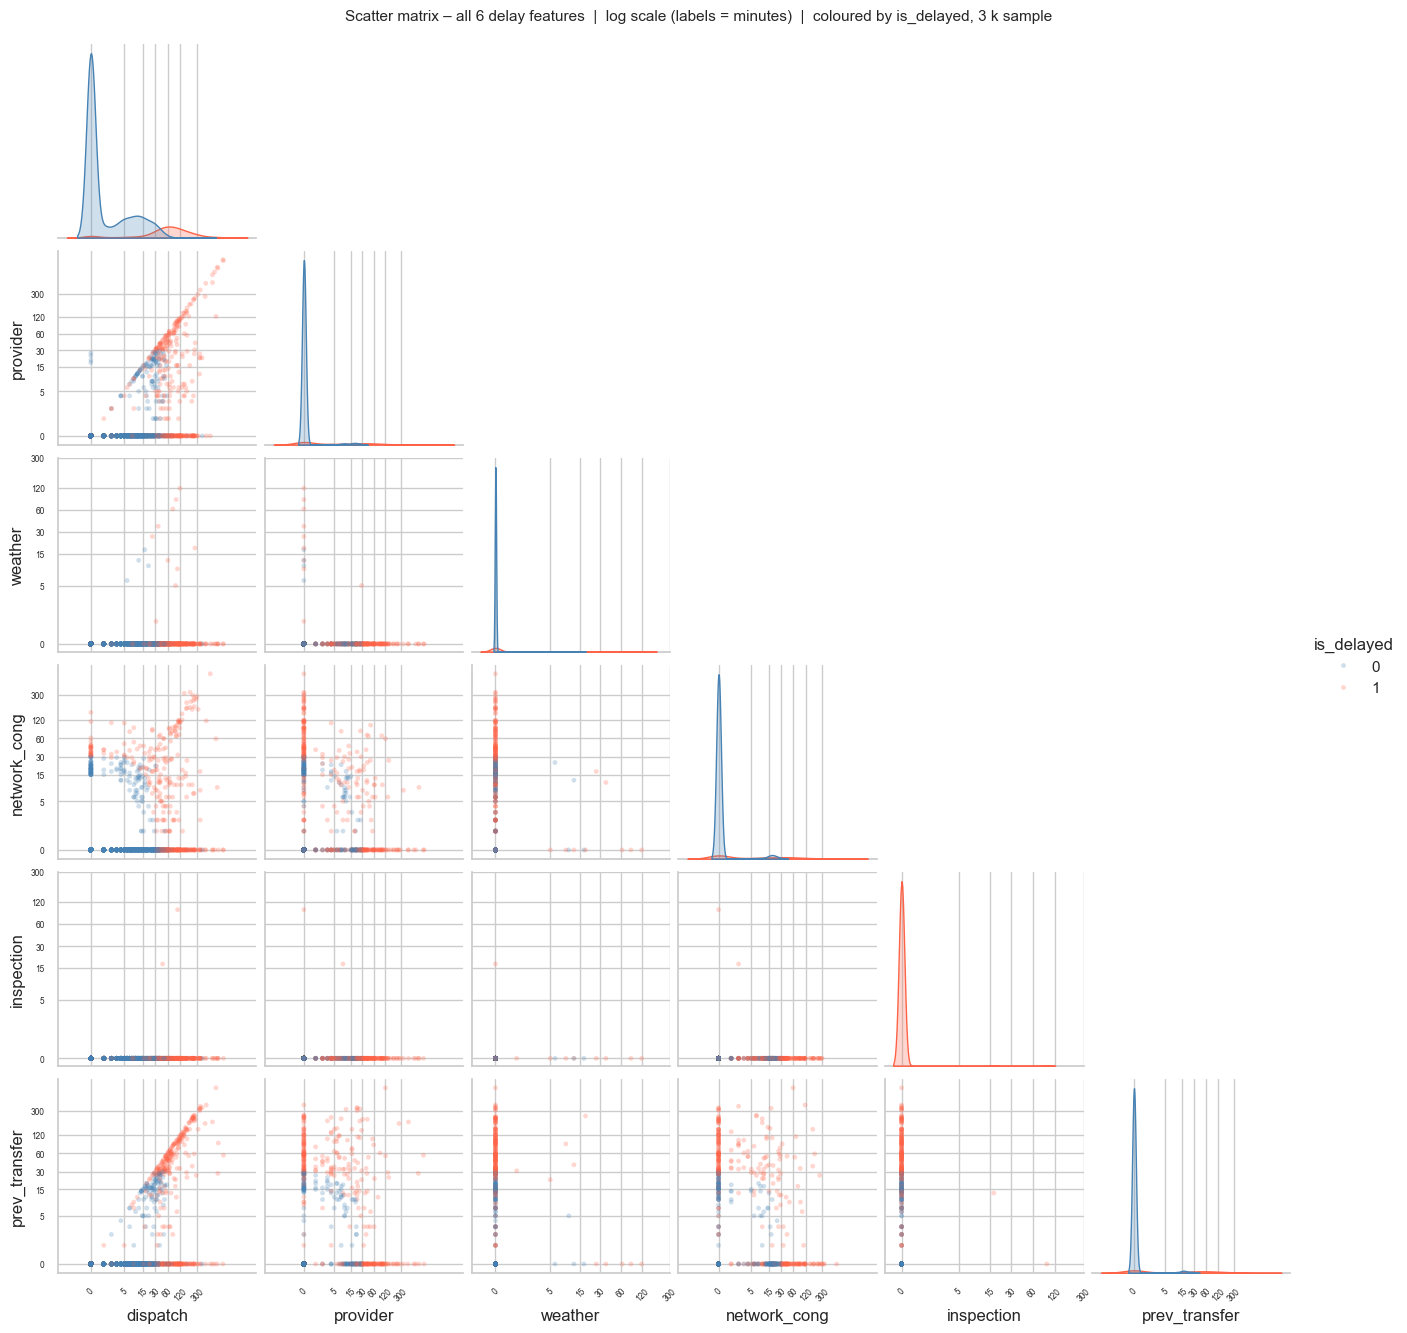

In [19]:

# Scatter plot matrix of ALL six delay features, coloured by target.
#
# All delay columns are zero-inflated with a heavy right tail, so a linear
# scale collapses most points onto (0, 0).  We log-transform the values
# (shifting by 1 to handle zeros) so the informative small-delay region
# spreads out while extreme outliers are compressed.

pairplot_cols = [
    "expected_dispatch_delay_minutes",
    "expected_provider_delay_minutes",
    "expected_weather_disruption_minutes",
    "expected_network_congestion_delay_minutes",
    "expected_inspection_delay_minutes",
    "expected_previous_transfer_delay_minutes",
]
short_names = [
    "dispatch",
    "provider",
    "weather",
    "network_cong",
    "inspection",
    "prev_transfer",
]

sample_pp = df[pairplot_cols + [TARGET]].sample(3000, random_state=RANDOM_STATE).copy()

# Log-transform: log1p(max(x, 0)) to handle zeros and negatives safely.
# Negative values (e.g. early dispatch) are clipped to 0 before the transform.
plot_data = pd.DataFrame(
    {short: np.log1p(sample_pp[col].clip(lower=0).values)
     for col, short in zip(pairplot_cols, short_names)},
)
plot_data[TARGET] = sample_pp[TARGET].values

# Readable tick positions in original minutes, mapped through log1p
ref_minutes = [0, 5, 15, 30, 60, 120, 300]
tick_vals = [np.log1p(m) for m in ref_minutes]
tick_labels = [str(m) for m in ref_minutes]

g = sns.pairplot(
    plot_data,
    hue=TARGET,
    palette={0: "steelblue", 1: "tomato"},
    plot_kws={"alpha": 0.25, "s": 12, "linewidth": 0},
    diag_kind="kde",
    corner=True,
    height=2.2,
    aspect=1,
)

for ax in g.axes.flatten():
    if ax is None:
        continue
    ax.set_xticks(tick_vals)
    ax.set_xticklabels(tick_labels, fontsize=6, rotation=45)
    ax.set_yticks(tick_vals)
    ax.set_yticklabels(tick_labels, fontsize=6)

g.figure.suptitle(
    "Scatter matrix – all 6 delay features  |  log scale (labels = minutes)"
    "  |  coloured by is_delayed, 3 k sample",
    y=1.01,
    fontsize=11,
)
plt.show()


### Q6 – Do any anonymous features look influential on the target?

We treat two groups of features as "anonymous" — their real-world meaning is hidden or encoded as opaque IDs:

1. **Numeric `internal_*` features** — five columns whose semantics are unknown. We compute the Spearman correlation with `is_delayed` and show the per-class distribution via boxplots.
2. **Categorical ID features** — `source_facility`, `destination_facility`, `source_region`, `destination_region`. These are encoded as opaque string codes with no disclosed geography or hierarchy. We compute the delay rate per category and show the top & bottom 10 to reveal whether specific IDs are systematically high- or low-risk.


Spearman correlation of internal_* features with is_delayed:
internal_timestamp_a          0.241
internal_timestamp_b          0.159
internal_metric_a             0.145
internal_metric_b             0.063
internal_operational_score    0.000
Name: is_delayed, dtype: float64


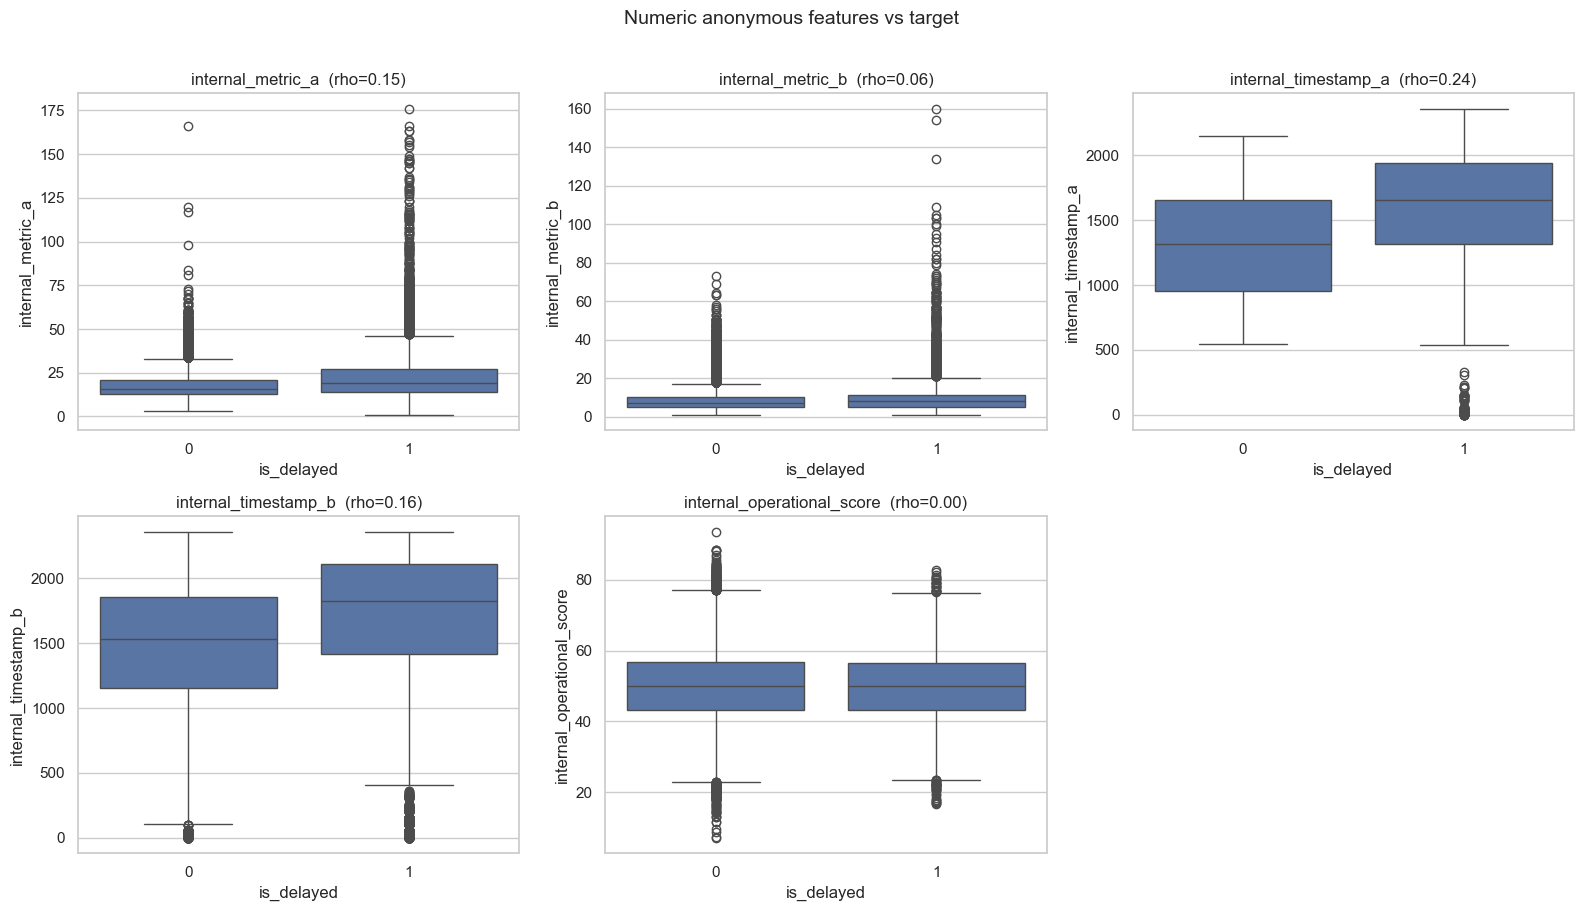

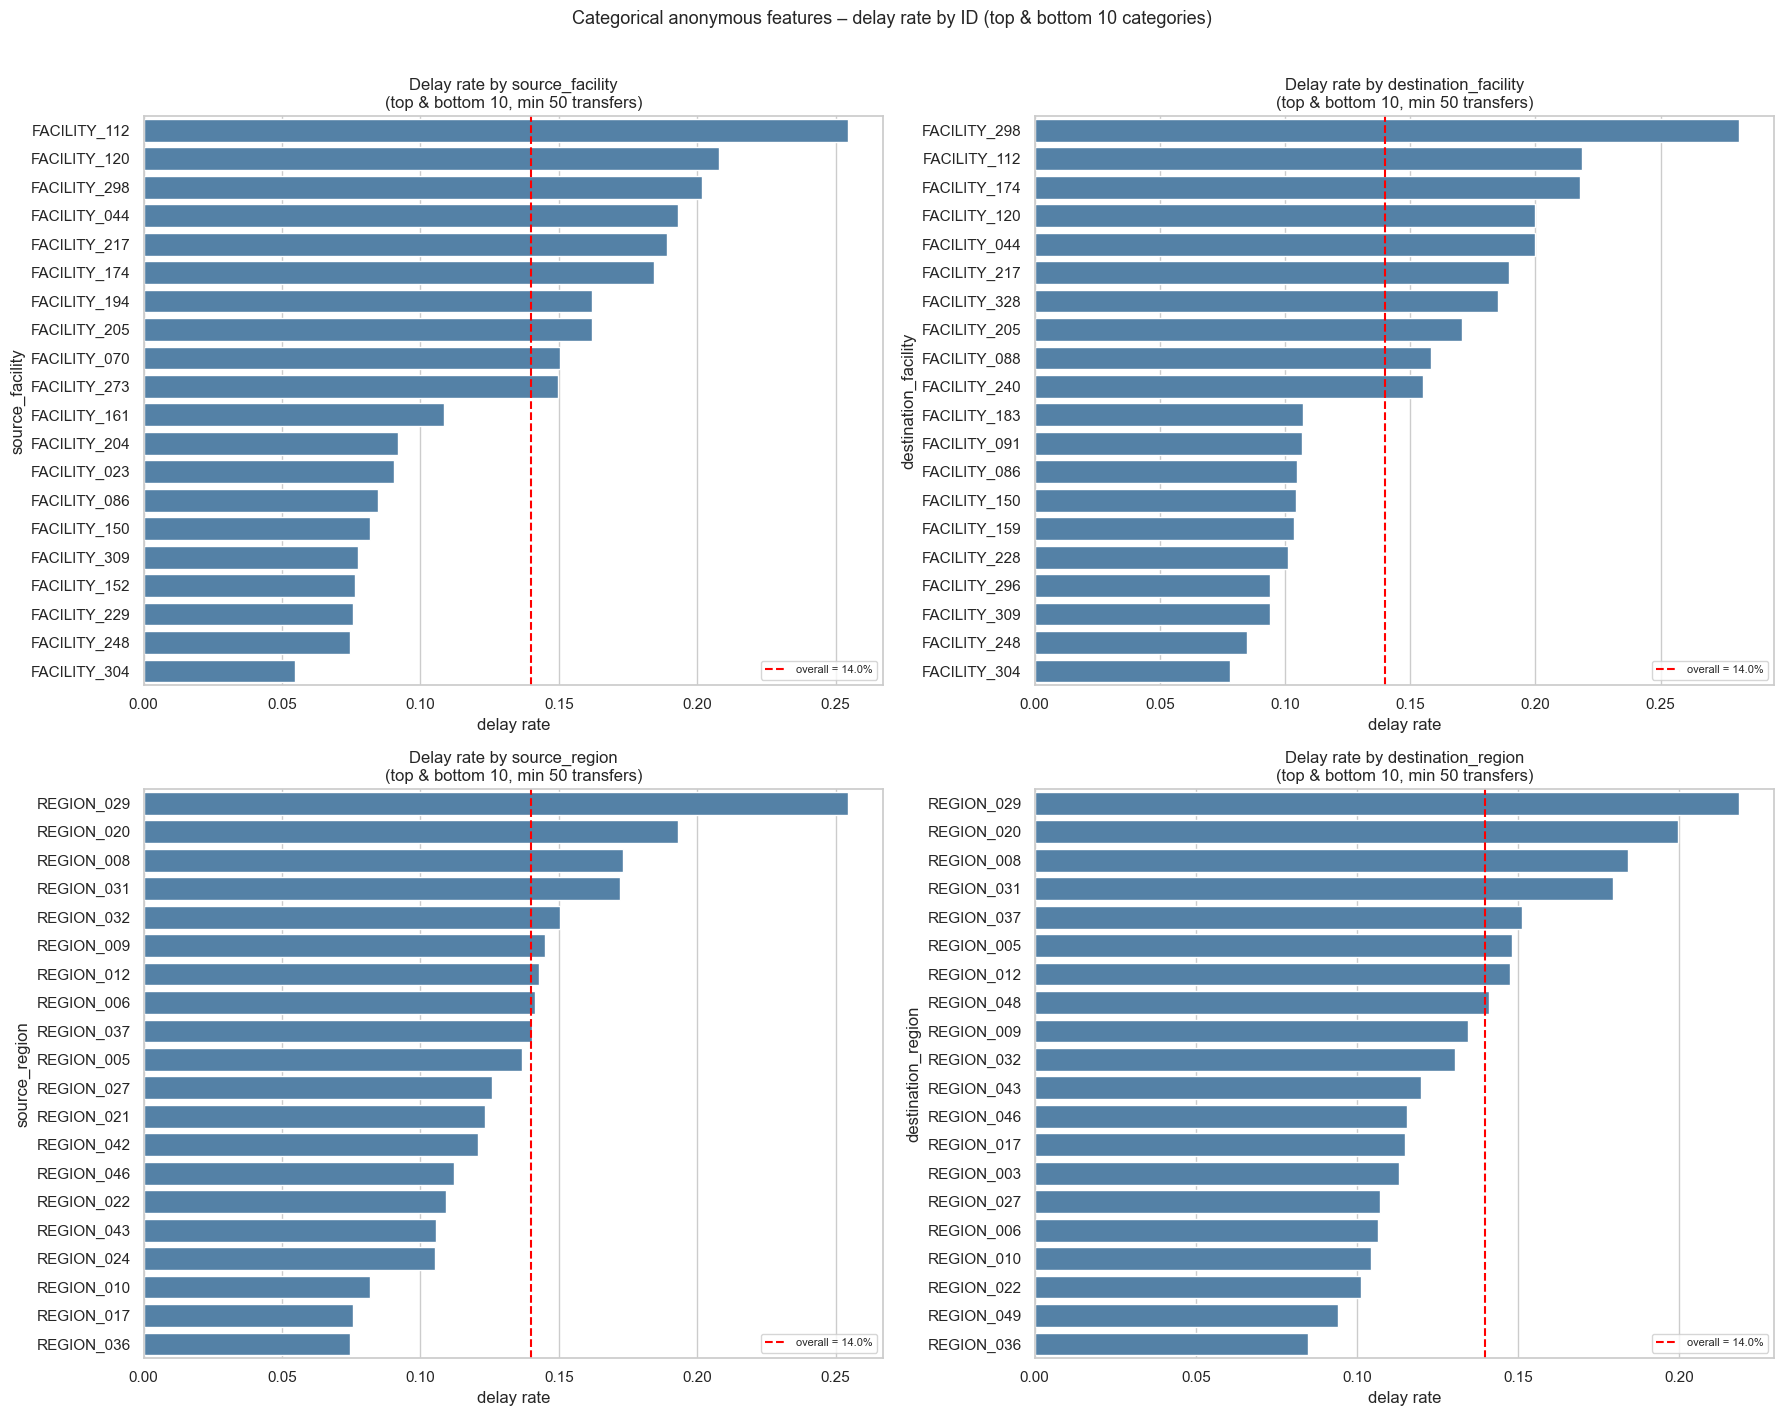


Delay-rate spread per categorical anonymous feature:
  source_facility                 min=5.5%  max=25.4%  n_categories=40
  destination_facility            min=7.8%  max=28.1%  n_categories=40
  source_region                   min=7.5%  max=25.4%  n_categories=24
  destination_region              min=8.5%  max=21.9%  n_categories=24


In [20]:

# ── Part A: Numeric internal_* features ──────────────────────────────────────
anon_corr = (df[anon_cols + [TARGET]].corr(method="spearman")[TARGET]
             .drop(TARGET).sort_values(key=np.abs, ascending=False))
print("Spearman correlation of internal_* features with is_delayed:")
print(anon_corr.round(3))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, anon_cols):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
    ax.set_title(f"{col}  (rho={anon_corr[col]:.2f})")
    ax.set_xlabel("is_delayed")
for ax in axes[len(anon_cols):]:
    ax.set_visible(False)
fig.suptitle("Numeric anonymous features vs target", y=1.01, fontsize=14)
fig.tight_layout()
plt.show()

# ── Part B: Categorical anonymous ID features (facilities & regions) ──────────
# source_facility, destination_facility, source_region, destination_region are
# all encoded as opaque IDs with no disclosed meaning — making them anonymous.
# We show the delay rate for the top & bottom 10 categories (min 50 transfers).
cat_anon_cols = [
    "source_facility",
    "destination_facility",
    "source_region",
    "destination_region",
]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for ax, col in zip(axes, cat_anon_cols):
    rate = df.groupby(col)[TARGET].agg(delay_rate="mean", n="count")
    rate = rate[rate["n"] >= 50].sort_values("delay_rate", ascending=False)
    extremes = pd.concat([rate.head(10), rate.tail(10)]).drop_duplicates()
    sns.barplot(data=extremes.reset_index(), y=col, x="delay_rate",
                color="steelblue", ax=ax)
    ax.axvline(overall_rate, color="red", linestyle="--",
               label=f"overall = {overall_rate:.1%}")
    ax.set_title(f"Delay rate by {col}\n(top & bottom 10, min 50 transfers)")
    ax.set_xlabel("delay rate")
    ax.legend(fontsize=8)

fig.suptitle(
    "Categorical anonymous features – delay rate by ID (top & bottom 10 categories)",
    y=1.01, fontsize=13,
)
fig.tight_layout()
plt.show()

# Spread summary for all categorical anonymous features
print("\nDelay-rate spread per categorical anonymous feature:")
for col in cat_anon_cols:
    rate = df.groupby(col)[TARGET].agg(delay_rate="mean", n="count")
    rate = rate[rate["n"] >= 50]
    print(f"  {col:30s}  min={rate['delay_rate'].min():.1%}  "
          f"max={rate['delay_rate'].max():.1%}  "
          f"n_categories={len(rate)}")


### Answer 6

**Numeric `internal_*` features:**
- `internal_timestamp_a` (ρ = 0.24) and `internal_timestamp_b` (ρ = 0.16) are the strongest anonymous predictors; the boxplots show clearly higher values for delayed transfers. Combined with their 0–2359 range, they most likely encode *actual* dispatch/arrival clock times, which naturally relate to lateness.
- `internal_metric_a` (ρ = 0.14) carries a mild signal; `internal_metric_b` (ρ = 0.06) is weak.
- `internal_operational_score` has ρ ≈ **0.00** and **identical distributions** in both classes – despite being the only nicely Gaussian feature, it looks like uninformative noise.

**Categorical ID features (facilities & regions):**
- **Facilities:** `source_facility` and `destination_facility` show substantial delay-rate variation across IDs (spread comparable to the region features). Certain facility codes are systematically high-risk, making them useful categorical predictors despite their opaque names.
- **Regions:** `source_region` and `destination_region` were examined in Q1 and show a wide spread (~7–25% delay rate). The same pattern is visible here: a handful of region IDs (`REGION_029`, etc.) are clear hotspots on both origin and destination sides.

All four categorical ID features carry real signal and should be encoded (e.g. target-encoding or leave-one-out encoding given the many categories) in the modelling phase.


### Q7: Which features look irrelevant / low-value for prediction?

This is the synthesis question. We pull together everything found in Q1–Q6 and add a single, comparable ranking of how strongly each feature relates to the target. To avoid relying on one statistic, every **numeric** feature is scored with three complementary measures:

- **Spearman ρ** – monotonic (rank) association, robust to the heavy tails of the delay columns.
- **Point-biserial correlation** – the linear (Pearson) association between a continuous feature and the binary target.
- **ANOVA F-test** – tests whether the feature's mean differs between on-time and delayed transfers (the significance test from class), reported as an F statistic and p-value.

For the **categorical** features (regions, facilities, provider, weekday) correlation is undefined, so we use the **delay-rate spread** (max − min over categories with at least 50 transfers) as the comparable measure of signal. Because the sample is large (~51k rows), almost every feature comes out "statistically significant" (p ≈ 0); we therefore judge low value by **effect size**, not by the p-value alone.


**What the earlier questions already told us about feature value:**

- **Q1** – `logistics_provider` and the region fields separate the delay rate strongly (≈9–25%): real signal.
- **Q2 (`dispatch_hour`)** – the departure hour is almost monotonic (7% → 21% across the day): a useful engineered feature.
- **Q3** – `expected_dispatch_delay_minutes` is the single strongest driver of a significant arrival delay.
- **Q4** – `route_distance_miles` is essentially flat across deciles (corr ≈ 0): a prime low-value candidate.
- **Q5** – four delay sources correlate well with the target, but `expected_inspection_delay_minutes` (ρ ≈ 0.03) stands out as near-useless.
- **Q6** – `internal_timestamp_a/b` and `internal_metric_a` carry signal; `internal_operational_score` (ρ ≈ 0) and `internal_metric_b` (ρ ≈ 0.06) are weak; the facility / region IDs carry signal.

The ranking below confirms these observations using the three numeric measures and the categorical delay-rate spread together.


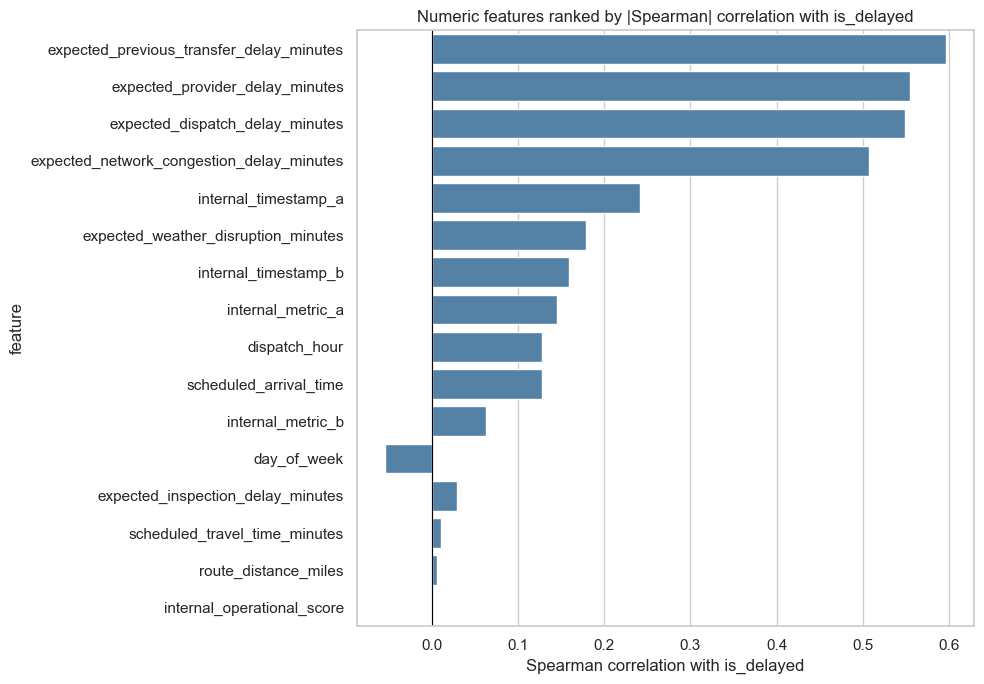

Categorical features – delay-rate spread (min 50 transfers per category):
                      n_categories  min_rate  max_rate  spread
feature                                                       
destination_facility            40     0.078     0.281   0.203
source_facility                 40     0.055     0.254   0.200
source_region                   24     0.075     0.254   0.180
day_of_week                      7     0.082     0.240   0.158
logistics_provider              14     0.094     0.235   0.140
destination_region              24     0.085     0.219   0.134

Note: with ~51k rows the ANOVA p-value is ~0 for almost every feature, so
statistical significance is necessary but NOT sufficient – we judge low value
by a small effect size (|correlation| and a flat delay rate), not by the p-value.

Numeric features – association with the target (sorted by |Spearman|):


,spearman,point_biserial,anova_F,anova_p
feature,,,,
expected_previous_transfer_delay_minutes,0.596,0.459,13614.888,0.000
expected_provider_delay_minutes,0.555,0.306,4890.403,0.000
expected_dispatch_delay_minutes,0.548,0.598,28123.694,0.000
expected_network_congestion_delay_minutes,0.507,0.380,7933.659,0.000
internal_timestamp_a,0.241,0.245,3223.109,0.000
expected_weather_disruption_minutes,0.179,0.112,581.605,0.000
internal_timestamp_b,0.159,0.106,573.473,0.000
internal_metric_a,0.145,0.238,2558.003,0.000
dispatch_hour,0.128,0.128,855.952,0.000


In [21]:
from scipy import stats

# Rank every NUMERIC feature by its association with the target using three
# complementary measures, so the conclusion does not rest on Spearman alone:
#   * Spearman rho   – monotonic (rank) association, robust to the heavy tails.
#   * Point-biserial – linear (Pearson) association between a continuous
#                      feature and the binary 0/1 target.
#   * ANOVA F-test   – tests whether the feature's mean differs between the
#                      on-time and delayed groups (F statistic + p-value),
#                      exactly the significance test discussed in class.
numeric_features = (df.select_dtypes(include=[np.number])
                      .columns.drop([TARGET, "scheduled_dispatch_time"]))

rows = []
for col in numeric_features:
    sub = df[[col, TARGET]].dropna()           # pairwise drop of missing values
    x, y = sub[col], sub[TARGET]
    rho = x.corr(y, method="spearman")
    r_pb = x.corr(y)                           # Pearson == point-biserial for a 0/1 target
    f_stat, p_val = stats.f_oneway(x[y == 0], x[y == 1])
    rows.append({"feature": col, "spearman": rho, "point_biserial": r_pb,
                 "anova_F": f_stat, "anova_p": p_val})

feature_assoc = pd.DataFrame(rows).set_index("feature")
feature_assoc = feature_assoc.reindex(
    feature_assoc["spearman"].abs().sort_values(ascending=False).index)
feature_strength = feature_assoc["spearman"]   # kept for the bar plot below

# Delay-rate spread for the CATEGORICAL features: correlation is undefined for
# them, so we measure how far the per-category delay rate moves from the 14%
# baseline (max - min over categories with at least 50 transfers).
cat_cols_q7 = ["logistics_provider", "source_region", "destination_region",
               "source_facility", "destination_facility", "day_of_week"]
cat_rows = []
for col in cat_cols_q7:
    rate = df.groupby(col)[TARGET].agg(delay_rate="mean", n="count")
    rate = rate[rate["n"] >= 50]
    cat_rows.append({"feature": col, "n_categories": len(rate),
                     "min_rate": rate["delay_rate"].min(),
                     "max_rate": rate["delay_rate"].max(),
                     "spread": rate["delay_rate"].max() - rate["delay_rate"].min()})
cat_assoc = pd.DataFrame(cat_rows).set_index("feature").sort_values(
    "spread", ascending=False)

# Visual: numeric features ranked by |Spearman| with the target
plt.figure(figsize=(10, 7))
sns.barplot(x=feature_strength.values, y=feature_strength.index, color="steelblue")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Numeric features ranked by |Spearman| correlation with is_delayed")
plt.xlabel("Spearman correlation with is_delayed")
plt.tight_layout()
plt.show()

print("Categorical features – delay-rate spread (min 50 transfers per category):")
print(cat_assoc.round(3).to_string())
print("\nNote: with ~51k rows the ANOVA p-value is ~0 for almost every feature, so")
print("statistical significance is necessary but NOT sufficient – we judge low value")
print("by a small effect size (|correlation| and a flat delay rate), not by the p-value.\n")
print("Numeric features – association with the target (sorted by |Spearman|):")
feature_assoc.round(3)


### Answer 7

**Yes – a small group of features carries little or no usable signal, and the three measures agree on which ones.**

**Irrelevant (no usable signal – not even statistically significant despite ~51k rows):**
- `internal_operational_score` – Spearman 0.00, point-biserial −0.001, ANOVA F = 0.04 (p = 0.84). The only Gaussian feature, but its distribution is identical in both classes: pure noise.
- `route_distance_miles` – Spearman 0.007, F = 2.03 (p = 0.16). Confirms Q4: distance on its own does not move the delay rate.

**Very low value (significant only because the sample is large, but the effect size is negligible, |r| ≤ 0.03):**
- `scheduled_travel_time_minutes` – |r| = 0.01 (p = 0.03).
- `expected_inspection_delay_minutes` – |r| = 0.03, F = 50. The weakest of the six delay sources by a wide margin.

**Looks weak by correlation but should keep (this is exactly why we used more than Spearman):**
- `day_of_week` – monotonic correlation is tiny (−0.05), yet its per-weekday delay rate spans ≈8–24% (spread 0.16). The effect is non-monotonic, so a single correlation hides it; it should be encoded categorically rather than dropped.
- `internal_metric_b` – borderline (Spearman 0.06 but point-biserial 0.10); keep for now and re-check with model-based importance.

**Conclusion.** `internal_operational_score` and `route_distance_miles` are the clearest features to drop, with `scheduled_travel_time_minutes` and `expected_inspection_delay_minutes` close behind – all four are weak under every measure (rank, linear and mean-difference).We remove `internal_operational_score` and `route_distance_miles` as they are irrelevant but We will **not** remove the rest blindly in this part. We can still expose value hidden in interactions, so we keep a shortlist to verify, not a final deletion. By contrast, every categorical field (provider, regions, facilities and weekday) shows a wide delay-rate spread and is worth keeping and encoding.


### Conclusions

- **Size & target.** The training set has **51,056 transfers and 23 columns**. The target `is_delayed` is binary and **imbalanced**: only ~**14%** of transfers are delayed by more than 30 minutes. AUC (the project metric) is a sensible choice given this imbalance.
- **Column roles.** We can group the columns into: *scheduling/time* fields (`scheduled_dispatch_time`, `scheduled_arrival_time`, `day_of_week`, `operation_date`), *route* fields (`scheduled_travel_time_minutes`, `route_distance_miles`), six *expected delay* fields, five anonymous *internal_* fields, and *categorical* identifiers (regions, facilities, provider). The time fields are stored as integers in `HHMM` format (e.g. `830` = 08:30).
- **Missing values.** Nine columns contain missing values, the largest being `internal_metric_a` (16.3%), `expected_inspection_delay_minutes` (12.0%) and `internal_metric_b` (11.3%). No column is missing more than ~16%, so none should be dropped purely for missingness; we will impute them in the preprocessing phase.
- **Skew & outliers.** The six expected-delay columns are strongly **zero-inflated and right-skewed** (75th percentile is 0 for most of them, but maxima reach ~1,000–2,000 minutes). `expected_dispatch_delay_minutes` ranges from −22 (early dispatch) to 2,120 minutes. `route_distance_miles` has a clear outlier tail (max 14,342 vs. a 75th percentile of ~1,498). `internal_operational_score` looks roughly symmetric around 50. These point to heavy-tailed distributions that we examine next.

## Exploration Summary

Main takeaways from Part 1, to carry into preprocessing and modelling:

- **Target.** Binary and imbalanced (~14% delayed); AUC is the right metric.
- **Strongest predictors.** The expected-delay sources – `expected_previous_transfer_delay_minutes`, `expected_provider_delay_minutes`, `expected_dispatch_delay_minutes`, `expected_network_congestion_delay_minutes` – plus the engineered `dispatch_hour` and the anonymous `internal_timestamp_a/b`.
- **Departure → arrival propagation.** Departure delays above ~30 minutes translate into a very high probability of a significant arrival delay (60% at 30–60 min, 98% above 60 min).
- **Categorical signal.** Both `logistics_provider` and the region fields show large delay-rate differences; provider text needs whitespace normalisation.
- **Weak / noise features.** `route_distance_miles`, `scheduled_travel_time_minutes`, `expected_inspection_delay_minutes` and `internal_operational_score` show almost no marginal link to the target.
- **Preprocessing to-do (Part 2).** Handle missing values (up to ~16%), the heavy right tails / outliers in the delay columns, normalisation/scaling, categorical encoding, and re-check the weak features with model-based importance before dropping.

*Helper columns created during exploration (`dispatch_hour`, `dispatch_delay_bin`, `distance_bin`) are kept only for analysis; the formal feature engineering is done in Part 2.*

In [22]:
# The provider plot shows some codes twice -> check for inconsistent text (spaces / casing)
provider_counts = df["logistics_provider"].value_counts()
print(provider_counts)
print("\nRaw unique values (repr to expose whitespace/case):")
print([repr(v) for v in df["logistics_provider"].unique()])

logistics_provider
WN    10897
DL     9579
AA     9004
UA     8145
NK     2213
AS     2138
B6     2015
OO     2014
F9     1635
YX     1484
MQ      709
9E      599
OH      424
HA      188
G4       12
Name: count, dtype: int64

Raw unique values (repr to expose whitespace/case):
["'UA'", "'9E'", "'AA'", "'NK'", "'MQ'", "'HA'", "'G4'", "'F9'", "'DL'", "'B6'", "'AS'", "'WN'", "'OO'", "'YX'", "'OH'"]


## Part 2: Data Preprocessing

In this part we turn the raw table into a clean, fully numeric feature matrix that the models in Part 3 can consume. Every transformation is wrapped in a single scikit-learn `ColumnTransformer` / `Pipeline` object, which is **fit on the training split only** and then re-applied unchanged to the validation set and to the test set. This keeps the workflow reproducible and, more importantly, leakage-safe.

### Order of operations and why

The steps are applied in the following order:

1. **Train / validation split first.** Before computing *any* statistic (medians, scaling parameters, target-encoding values) we separate a validation set. If we fit these on the full data, information from the validation/test rows would leak into the training features and inflate our performance estimate.
2. **Feature construction.** All engineered features (departure/arrival hour, departure/arrival time in minutes, total expected delay, a missing-value counter) are purely row-local, so they are created right after the split. Doing this early means every later step (imputation, scaling, encoding) also processes the new columns.
3. **Missing-value imputation.** Done before outlier handling and scaling so that the later numeric steps never see `NaN`. We implement **two interchangeable strategies** (median or KNN) controlled by a single switch; both add a missing-value indicator.
4. **Outlier handling.** The heavy-tailed delay columns are compressed with a signed-log transform and then optionally winsorised (clipped to train quantiles, toggled by `USE_WINSORIZE`). This happens after imputation (no `NaN`) and before scaling, so the scaler is not distorted by the extreme tails.
5. **Normalisation / scaling.** A `StandardScaler` puts every numeric feature on a comparable scale. This must come after outlier taming, otherwise a few extreme values would dominate the mean and standard deviation.
6. **Categorical encoding.** Low-cardinality fields are one-hot encoded; the high-cardinality ID fields are target-encoded. Encoders are fit on the training fold only.
7. **Dimensionality.** We drop the features judged irrelevant in Part 1, prefer target encoding over one-hot for the ID fields to avoid a column explosion, and run a PCA experiment on the correlated delay block.
8. **Apply to the test set.** The same fitted pipeline is finally applied to `test.csv`.


In [23]:
# Preprocessing imports
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder, FunctionTransformer
from sklearn.decomposition import PCA

# --- Configuration switches -------------------------------------------------
# Missing-value strategy. Flip this single flag to swap the whole imputation
# approach; the rest of the notebook re-runs unchanged.
#   "median" -> median imputation + a binary missing-value indicator per column
#   "knn" -> K-Nearest-Neighbours imputation (distance based)
# Both strategies add the per-column missing-value indicators.
IMPUTE_METHOD = "median"
KNN_N_NEIGHBORS = 5 # only used when IMPUTE_METHOD == "knn"

WINSOR_LIMITS = (0.01, 0.99) # quantiles used to clip outliers (train-based)
USE_WINSORIZE = True # toggle outlier winsorising on/off to compare its effect
VAL_SIZE = 0.1 # fraction held out for validation

assert IMPUTE_METHOD in {"median", "knn"}
print(f"Imputation method: {IMPUTE_METHOD}")
print(f"Winsorising outliers: {USE_WINSORIZE}")


Imputation method: median
Winsorising outliers: True


### Reload the data and split before any fitting

Part 1 modified `df` in place (added helper columns, stripped text). To start preprocessing from a clean, well-defined state we reload the raw CSV into `df_raw`. We then immediately split it into a training and a validation set, **stratified on the target** so both sets keep the ~14% delayed rate.

The split is the very first thing we do: every transformer that *learns* something from the data (medians, scaling parameters, target-encoding tables) will be fit on the training set only. The validation set is treated exactly like unseen test data.


In [24]:
# Reload a clean copy of the raw training data (Part 1 mutated `df`).
df_raw = pd.read_csv(TRAIN_PATH)

X_raw = df_raw.drop(columns=[TARGET])
y = df_raw[TARGET]

# Stratified train/validation split, done before any model is fit.
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_raw, y,
    test_size=VAL_SIZE,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train_raw.shape, "| delayed rate:", round(y_train.mean(), 4))
print("Val:  ", X_val_raw.shape, "| delayed rate:", round(y_val.mean(), 4))


Train: (45950, 22) | delayed rate: 0.1399
Val:   (5106, 22) | delayed rate: 0.1398


### Feature construction (manipulating and building predictors)

Guided by Part 1, we build a small set of new predictors and drop the raw columns they replace. All of these are computed **per row**, so they introduce no leakage and can be applied identically to the test set.

- **`dispatch_hour`, `arrival_hour`** – the hour extracted from the `HHMM` time integers. Part 1 (Q2) showed the departure hour has a strong, near-monotonic effect on the delay rate, so the hour is more useful than the raw `HHMM` value (which jumps from `759` to `800`).
- **`dispatch_time`, `arrival_time`** – the same scheduled times expressed as **minutes since midnight** (`hour×60 + minute`). This keeps the finer within-hour resolution that the hour buckets throw away, while remaining a smooth, evenly-spaced numeric scale (unlike the raw `HHMM` integers).
- **`total_expected_delay`** – the sum of the six expected-delay columns. A single aggregate of "how much delay is expected from all sources" is a compact, strong signal.
- **`n_missing`** – the number of missing fields in the row. Missingness may not be random (e.g. records with incomplete logging could behave differently), so we keep it as an explicit feature.

We also drop the two features Part 1 found to be pure noise (`route_distance_miles`, `internal_operational_score`) and the raw `HHMM`/date columns that have been replaced (`operation_date` is dropped without a calendar feature). The anonymous `internal_timestamp_a/b` are kept as numeric features (Part 1 found they carry signal). The function is written once and reused for the training, validation and test data.


In [25]:
# Raw columns that are dropped after engineering (replaced or judged irrelevant).
RAW_DELAY_COLS = [
    "expected_dispatch_delay_minutes",
    "expected_provider_delay_minutes",
    "expected_weather_disruption_minutes",
    "expected_network_congestion_delay_minutes",
    "expected_inspection_delay_minutes",
    "expected_previous_transfer_delay_minutes",
]
DROP_COLS = [
    "route_distance_miles",        # Part 1: no signal
    "internal_operational_score",  # Part 1: pure noise
    "scheduled_dispatch_time",     # replaced by dispatch_hour / dispatch_time
    "scheduled_arrival_time",      # replaced by arrival_hour / arrival_time
    "operation_date",              # dropped (no calendar feature kept)
]


def engineer_features(data):
    """Build engineered predictors from the raw transfer table.

    The transformation is purely row-local (no statistics learned across rows),
    so it can be applied to train, validation and test data without leakage.
    `is_delayed` / `transfer_id` are dropped here if present; they are handled
    by the caller.
    """
    data = data.copy()

    # Normalise text fields (fixes the trailing-whitespace provider duplicates).
    text_cols = data.select_dtypes(include="object").columns
    data[text_cols] = data[text_cols].apply(lambda s: s.str.strip())

    # Count missing fields per row before we impute anything (missingness signal).
    data["n_missing"] = data.isnull().sum(axis=1)

    # Hour of day from the HHMM time integers.
    data["dispatch_hour"] = data["scheduled_dispatch_time"] // 100
    data["arrival_hour"] = data["scheduled_arrival_time"] // 100

    # Minutes since midnight from the HHMM time integers (finer-grained than the
    # hour alone): HHMM -> hour*60 + minute.
    data["dispatch_time"] = ((data["scheduled_dispatch_time"] // 100) * 60
                             + data["scheduled_dispatch_time"] % 100)
    data["arrival_time"] = ((data["scheduled_arrival_time"] // 100) * 60
                            + data["scheduled_arrival_time"] % 100)

    # Aggregate expected delay across all sources (missing treated as 0 minutes).
    data["total_expected_delay"] = data[RAW_DELAY_COLS].sum(axis=1, skipna=True)

    # Remove raw columns that were replaced or found irrelevant in Part 1.
    drop_now = [c for c in DROP_COLS + [TARGET, "transfer_id"] if c in data.columns]
    return data.drop(columns=drop_now)


X_train = engineer_features(X_train_raw)
X_val = engineer_features(X_val_raw)

print("Engineered feature columns:", X_train.shape[1])
X_train.head()


Engineered feature columns: 23


,day_of_week,expected_dispatch_delay_minutes,source_facility,source_region,destination_facility,destination_region,logistics_provider,scheduled_travel_time_minutes,expected_provider_delay_minutes,expected_weather_disruption_minutes,...,internal_metric_a,internal_metric_b,internal_timestamp_a,internal_timestamp_b,n_missing,dispatch_hour,arrival_hour,dispatch_time,arrival_time,total_expected_delay
47958,7,2.0,FACILITY_194,REGION_031,FACILITY_240,REGION_012,OO,174.0,0.0,0.0,...,19.0,20.0,1208.0,1334.0,1,12,13,735,836,2.0
49740,7,7.0,FACILITY_205,REGION_008,FACILITY_088,REGION_048,AA,148.0,0.0,NaN,...,20.0,3.0,1625.0,1759.0,1,16,18,964,1101,7.0
2064,1,-6.0,FACILITY_174,REGION_031,FACILITY_298,REGION_005,DL,441.0,0.0,0.0,...,28.0,NaN,722.0,1036.0,1,7,10,420,648,-6.0
2158,1,-9.0,FACILITY_070,REGION_032,FACILITY_021,REGION_009,DL,82.0,NaN,NaN,...,NaN,5.0,1657.0,1734.0,3,17,18,1022,1098,-9.0
32172,5,34.0,FACILITY_183,REGION_027,FACILITY_099,REGION_021,DL,251.0,1.0,0.0,...,20.0,11.0,1647.0,2244.0,1,15,22,938,1350,63.0


In [26]:
# Column groups for the ColumnTransformer, defined on the engineered features.
DELAY_FEATURES = RAW_DELAY_COLS  # heavy-tailed, zero-inflated -> signed-log + winsorise

NUMERIC_FEATURES = [
    "scheduled_travel_time_minutes",
    "internal_metric_a",
    "internal_metric_b",
    "internal_timestamp_a",
    "internal_timestamp_b",
    "dispatch_hour",
    "arrival_hour",
    "dispatch_time",
    "arrival_time",
    "total_expected_delay",
    "n_missing",
]
# Low-cardinality categoricals -> one-hot encoding.
ONEHOT_FEATURES = ["logistics_provider", "day_of_week"]
# High-cardinality opaque IDs -> target encoding (avoids a huge one-hot matrix).
TARGET_FEATURES = ["source_region", "destination_region",
                   "source_facility", "destination_facility"]

assert set(DELAY_FEATURES + NUMERIC_FEATURES + ONEHOT_FEATURES + TARGET_FEATURES) == set(X_train.columns)


# Signed log: sign(x) * log1p(|x|). Compresses the heavy tails of the delay
# columns while preserving the negative early-dispatch values and keeping 0 at 0.
def signed_log1p(X):
    return np.sign(X) * np.log1p(np.abs(X))


signed_log = FunctionTransformer(signed_log1p, feature_names_out="one-to-one")


class Winsorizer(BaseEstimator, TransformerMixin):
    """Clip each column to quantile bounds learned on the training fold."""

    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lo_ = np.nanquantile(X, self.lower, axis=0)
        self.hi_ = np.nanquantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return np.clip(X, self.lo_, self.hi_)

    def get_feature_names_out(self, input_features=None):
        return np.asarray(input_features, dtype=object)


print(f"{len(DELAY_FEATURES)} delay | {len(NUMERIC_FEATURES)} numeric | "
      f"{len(ONEHOT_FEATURES)} one-hot | {len(TARGET_FEATURES)} target-encoded")


6 delay | 11 numeric | 2 one-hot | 4 target-encoded


### Is there missing data? How is it handled?

**Yes.** Part 1 found nine columns with missing values, up to ~16% (`internal_metric_a` 16.3%, `expected_inspection_delay_minutes` 12.0%, `internal_metric_b` 11.3%). No column is missing enough to justify dropping it, so we **impute**. The table below recomputes the missing rate on the *training fold* (the only data we are allowed to learn from).

We implement **two interchangeable strategies**, selected by the single `IMPUTE_METHOD` switch defined at the top of Part 2:

1. **`"median"` (default): median imputation + a missing-value indicator.** Each numeric column is filled with its training median, and a separate binary column flags which values were originally missing. The median is robust to the heavy right tails of the delay columns (far better than the mean), and the indicator lets the model use *the fact that a value was missing* as a signal in case missingness is informative.
2. **`"knn"`: K-Nearest-Neighbours imputation.** Each missing value is filled from the average of its `k=5` most similar rows. Because KNN is distance based, we standardise the numeric block *before* the KNN step so that a wide-range column (e.g. the 0–2359 timestamps) does not dominate the distance. KNN can be more accurate than a single global median because it conditions on similar transfers, at the cost of being slower.

The binary **missing-value indicator is added for both strategies**, so the model always sees *which* values were originally missing regardless of how they were filled.


We use the **median + indicator** method in the final workflow: it is simple, fast, robust and keeps the missingness signal explicit. The KNN variant is kept as an alternative that can be switched on with one flag.

In [27]:
# Missing rate per feature on the training fold (engineered features).
train_missing = pd.DataFrame({
    "missing_count": X_train.isnull().sum(),
    "missing_pct": (X_train.isnull().mean() * 100).round(2),
})
train_missing = train_missing[train_missing["missing_count"] > 0] \
    .sort_values("missing_pct", ascending=False)
train_missing


,missing_count,missing_pct
internal_metric_a,7504,16.33
expected_inspection_delay_minutes,5544,12.07
internal_metric_b,5172,11.26
expected_weather_disruption_minutes,4580,9.97
expected_network_congestion_delay_minutes,3672,7.99
expected_provider_delay_minutes,3203,6.97
internal_timestamp_b,603,1.31
internal_timestamp_a,593,1.29
expected_dispatch_delay_minutes,549,1.19


### Are there outliers? How are they handled?

**Yes.** Part 1 showed that the six expected-delay columns are zero-inflated with extreme right tails (single values up to ~2,000 minutes), and `total_expected_delay` inherits the same shape. These extremes are *genuine* operational events, not data-entry errors, and we must still produce a prediction for every test row, so **we do not delete any rows**. Instead we tame the tails in two steps:

1. **Signed-log transform** `sign(x)·log1p(|x|)` on the delay columns. This compresses the heavy right tail, keeps the zero spike at zero, and preserves the small negative "early dispatch" values.
2. **Winsorising** – after the transform we clip every numeric column to its 1st/99th training-set percentiles. This caps the few remaining extreme values so they cannot dominate the scaler or the distance-based models, while keeping the bulk of the distribution intact. This step is **toggleable** via the `USE_WINSORIZE` flag so its effect on the models can be measured with and without it.

Both bounds are learned on the training fold only and re-applied to validation/test. The plot below shows the effect of the signed-log step on one delay column.


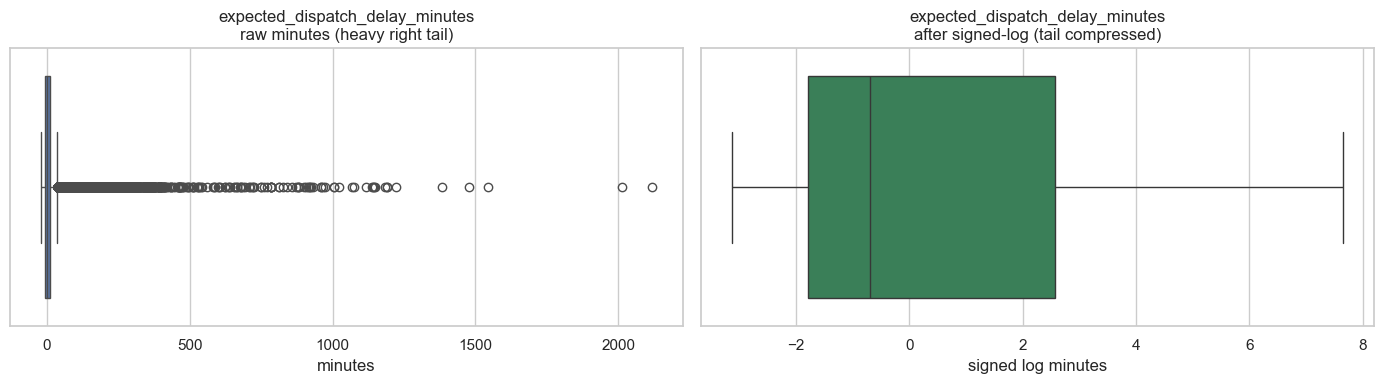

raw max = 2120 min  ->  signed-log max = 7.66


In [28]:
# Illustrate the outlier-taming effect of the signed-log transform on one column.
demo_col = "expected_dispatch_delay_minutes"
raw_vals = X_train[demo_col].dropna()
logged_vals = signed_log1p(raw_vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=raw_vals, ax=axes[0])
axes[0].set_title(f"{demo_col}\nraw minutes (heavy right tail)")
axes[0].set_xlabel("minutes")

sns.boxplot(x=logged_vals, ax=axes[1], color="seagreen")
axes[1].set_title(f"{demo_col}\nafter signed-log (tail compressed)")
axes[1].set_xlabel("signed log minutes")

fig.tight_layout()
plt.show()

print(f"raw max = {raw_vals.max():.0f} min  ->  signed-log max = {logged_vals.max():.2f}")


### Is the data normalised? Does it need to be?

**No, the raw data is not normalised** – the features live on wildly different scales: delays in minutes (0–2,000), `internal_timestamp_*` on a 0–2359 clock, `dispatch_time`/`arrival_time` 0–1439 minutes, `day_of_week` 1–7, `n_missing` 0–9. We therefore standardise every numeric feature with a `StandardScaler` (subtract the training mean, divide by the training standard deviation), fit on the training fold only.

**Why it matters here.** In Part 3 we will use distance- and gradient-based models (KNN, Logistic Regression, SVM, a neural network). For these, a feature's influence scales with its numeric range, so without normalisation the large-range columns (timestamps, delay minutes) would dominate the distance metric and slow or distort the optimisation. Standardising puts all features on equal footing. The KNN *imputer* needs the same treatment, which is why the `"knn"` branch standardises before imputing. (Tree-based models such as Random Forest are scale-invariant and would not strictly require this, but a single scaled matrix that works for every model keeps the pipeline simple.)


### Handling categorical variables

The categorical fields split naturally into two groups by cardinality, and we encode them differently:

- **Low cardinality → one-hot encoding** (`logistics_provider`, 14 codes after whitespace cleanup; `day_of_week`, 7 values). One-hot keeps every category as its own indicator without imposing a false order, and 14 + 7 columns is cheap. `handle_unknown="ignore"` makes the encoder robust to any provider/day that appears only in the test set.
- **High cardinality → target (mean) encoding** (`source_region`, `destination_region`, `source_facility`, `destination_facility` – dozens to hundreds of opaque IDs each). One-hot encoding these would add hundreds of sparse columns and blow up the dimensionality. Instead each category is replaced by the **mean delay rate of that category**, learned only on the training fold. scikit-learn's `TargetEncoder` uses internal cross-fitting and smoothing toward the global rate, which protects against overfitting on rare categories and leakage. Part 1 showed these IDs have a wide delay-rate spread, so this single numeric column per field captures most of their signal.

`day_of_week` is treated as categorical (one-hot) rather than numeric because Part 1 (Q7) showed its effect on the delay rate is non-monotonic, so an ordinal encoding would be misleading.


In [29]:
def build_preprocessor(method="median"):
    """Assemble the full preprocessing ColumnTransformer.

    `method` selects the imputation strategy and keeps every other step fixed:
      "median" -> SimpleImputer(median) + a separate MissingIndicator branch
      "knn"    -> scale (NaN-aware) -> KNNImputer
    Both strategies add explicit per-column missing-value indicators.
    Delay columns additionally get the signed-log transform up front, every
    numeric column is standardised, and winsorising is applied when
    `USE_WINSORIZE` is on.
    """
    # Winsorising is optional so its effect on the models can be compared.
    winsor_step = [("winsor", Winsorizer(*WINSOR_LIMITS))] if USE_WINSORIZE else []

    if method == "median":
        delay_steps = [
            ("signed_log", signed_log),
            ("impute", SimpleImputer(strategy="median")),
            *winsor_step,
            ("scale", StandardScaler()),
        ]
        num_steps = [
            ("impute", SimpleImputer(strategy="median")),
            *winsor_step,
            ("scale", StandardScaler()),
        ]
    else:  # "knn": StandardScaler ignores NaN in fit, so KNN works on a fair scale
        delay_steps = [
            ("signed_log", signed_log),
            ("scale", StandardScaler()),
            ("knn", KNNImputer(n_neighbors=KNN_N_NEIGHBORS)),
            *winsor_step,
        ]
        num_steps = [
            ("scale", StandardScaler()),
            ("knn", KNNImputer(n_neighbors=KNN_N_NEIGHBORS)),
            *winsor_step,
        ]

    branches = [
        ("delay", Pipeline(delay_steps), DELAY_FEATURES),
        ("num", Pipeline(num_steps), NUMERIC_FEATURES),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ONEHOT_FEATURES),
        ("target", TargetEncoder(random_state=RANDOM_STATE), TARGET_FEATURES),
        # Explicit per-column missing-value indicators, kept for both strategies
        # so the model always sees *which* values were originally missing.
        ("missing_flags", MissingIndicator(features="missing-only"),
         DELAY_FEATURES + NUMERIC_FEATURES),
    ]

    return ColumnTransformer(branches, remainder="drop",
                             verbose_feature_names_out=False)


preprocessor = build_preprocessor(IMPUTE_METHOD)
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('delay', ...), ('num', ...), ...]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}""``. See :meth:`str.format` method from the standard library for more info... versionadded:: 1.0.. versionchanged:: 1.6 `verbose_feature_names_out` can be a callable or a string to be formatted.",False
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transform

In [30]:
# Fit on the training fold only, then transform train and validation.
# fit_transform lets TargetEncoder use its leakage-safe cross-fitting on train.
X_train_proc = preprocessor.fit_transform(X_train, y_train)
X_val_proc = preprocessor.transform(X_val)

feature_names = preprocessor.get_feature_names_out()
X_train_proc = pd.DataFrame(X_train_proc, columns=feature_names, index=X_train.index)
X_val_proc = pd.DataFrame(X_val_proc, columns=feature_names, index=X_val.index)

# Sanity checks: nothing missing, train and validation share the same columns.
assert not X_train_proc.isnull().any().any(), "NaNs remain in processed train"
assert not X_val_proc.isnull().any().any(), "NaNs remain in processed val"
assert list(X_train_proc.columns) == list(X_val_proc.columns)

print(f"Processed train: {X_train_proc.shape} | val: {X_val_proc.shape}")
print(f"Total features after encoding: {X_train_proc.shape[1]}")
X_train_proc.head()


Processed train: (45950, 52) | val: (5106, 52)
Total features after encoding: 52


/opt/miniconda3/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


,expected_dispatch_delay_minutes,expected_provider_delay_minutes,expected_weather_disruption_minutes,expected_network_congestion_delay_minutes,expected_inspection_delay_minutes,expected_previous_transfer_delay_minutes,scheduled_travel_time_minutes,internal_metric_a,internal_metric_b,internal_timestamp_a,...,destination_facility,missingindicator_expected_dispatch_delay_minutes,missingindicator_expected_provider_delay_minutes,missingindicator_expected_weather_disruption_minutes,missingindicator_expected_network_congestion_delay_minutes,missingindicator_expected_inspection_delay_minutes,missingindicator_internal_metric_a,missingindicator_internal_metric_b,missingindicator_internal_timestamp_a,missingindicator_internal_timestamp_b
47958,0.310466,-0.329173,0.0,-0.333265,0.0,-0.338960,-0.122414,0.146905,2.290926,-0.373245,...,0.170230,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
49740,0.722707,-0.329173,0.0,-0.333265,0.0,-0.338960,-0.434548,0.279087,-1.042594,0.652277,...,0.147174,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2064,-0.969139,-0.329173,0.0,-0.333265,0.0,-0.338960,2.921021,1.336542,-0.258236,-1.568456,...,0.293759,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2158,-1.119049,-0.329173,0.0,-0.333265,0.0,-0.338960,-1.226891,-0.249641,-0.650415,0.730974,...,0.132213,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
32172,1.343027,0.368650,0.0,-0.333265,0.0,2.596332,0.801986,0.279087,0.526121,0.706381,...,0.126101,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


### Assessment of the problem's dimensionality

The raw table has 22 predictors, but the *effective* dimensionality is what matters. Our choices keep it modest:

- **Feature selection.** We dropped the features Part 1 found to be noise (`route_distance_miles`, `internal_operational_score`) and replaced four raw time/date columns with more informative engineered ones, so we add signal without inflating the count.
- **Encoding choice controls the blow-up.** The high-cardinality ID fields (regions, facilities) have dozens–hundreds of categories each; one-hot encoding all four would create hundreds of sparse columns and risk the curse of dimensionality. **Target encoding collapses each of them to a single dense numeric column**, which is the main dimensionality-control decision here. Only the genuinely low-cardinality fields are one-hot encoded.

The result is a compact matrix (≈30 columns, mostly dense). With ~40k training rows this is a comfortable rows-to-columns ratio, so aggressive dimensionality *reduction* is not strictly necessary. Still, Part 1 (Q5) showed the six delay columns are moderately correlated, so as an **experiment** we run PCA on that block to quantify the redundancy. We do **not** feed the PCA output into the final pipeline – it is kept only to document the analysis, since collapsing the delay columns would cost interpretability for little gain.


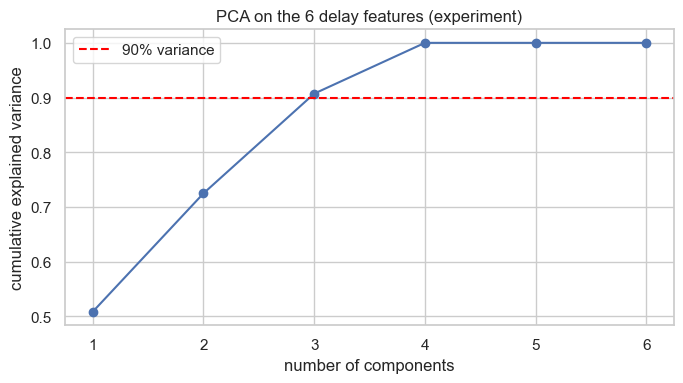

3 of 6 components explain >=90% of the delay-block variance.
Kept as analysis only; the final feature matrix uses the original delay columns.


In [31]:
# Experiment (not used in the final workflow): how much do the 6 delay columns
# overlap? PCA on the already-processed delay features quantifies the redundancy.
delay_proc_cols = [c for c in feature_names if c in DELAY_FEATURES]
pca_demo = PCA().fit(X_train_proc[delay_proc_cols])
cum_var = np.cumsum(pca_demo.explained_variance_ratio_)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o")
plt.axhline(0.9, color="red", linestyle="--", label="90% variance")
plt.title("PCA on the 6 delay features (experiment)")
plt.xlabel("number of components")
plt.ylabel("cumulative explained variance")
plt.xticks(range(1, len(cum_var) + 1))
plt.legend()
plt.tight_layout()
plt.show()

n_90 = int(np.argmax(cum_var >= 0.9) + 1)
print(f"{n_90} of {len(delay_proc_cols)} components explain >=90% of the delay-block variance.")
print("Kept as analysis only; the final feature matrix uses the original delay columns.")


### Applying the preprocessing to the test set

The test set must go through the **exact same** transformations as the training set, using the parameters already learned (medians, winsor bounds, scaler statistics, encodings). Because everything is wrapped in the fitted `preprocessor`, applying it to the test set is a single call to `engineer_features` followed by `preprocessor.transform`.

The function below is reusable: when the course provides `test.csv` it loads it, keeps the `transfer_id` aside for the submission file, runs the identical pipeline and returns a processed matrix aligned to the training columns. If `test.csv` is not present yet, the cell simply reports that and skips – it will work unchanged once the file is added.


In [32]:
def preprocess_test(path, fitted_preprocessor):
    """Apply the fitted preprocessing pipeline to a raw test CSV.

    Returns (transfer_id, X_test_proc). `transfer_id` is preserved for the
    submission file; if the column is absent a simple range index is used.
    """
    test_raw = pd.read_csv(path)

    if "transfer_id" in test_raw.columns:
        transfer_id = test_raw["transfer_id"].copy()
    else:
        transfer_id = pd.Series(range(1, len(test_raw) + 1), name="transfer_id")

    X_test = engineer_features(test_raw)
    X_test_proc = fitted_preprocessor.transform(X_test)
    X_test_proc = pd.DataFrame(X_test_proc, columns=feature_names, index=test_raw.index)
    return transfer_id, X_test_proc


if TEST_PATH.exists():
    test_id, X_test_proc = preprocess_test(TEST_PATH, preprocessor)
    assert list(X_test_proc.columns) == list(X_train_proc.columns)
    assert not X_test_proc.isnull().any().any(), "NaNs remain in processed test"
    print(f"Processed test: {X_test_proc.shape} (matches train columns).")
else:
    print(f"'{TEST_PATH}' not found yet - the test set will be processed with this "
          "same function once the file is provided for Part 5.")


'data/regional_logistics_transfers_test.csv' not found yet - the test set will be processed with this same function once the file is provided for Part 5.


### Preprocessing summary

What Part 2 produced, to carry into modelling:

- **Split first.** A stratified 90/10 train/validation split is made before any transformer is fit, so all statistics are learned on the training fold only and the validation set stays a fair proxy for the test set.
- **Engineered predictors.** `dispatch_hour`, `arrival_hour`, `dispatch_time`, `arrival_time`, `total_expected_delay` and `n_missing` are added; the two noise features and the replaced raw time/date columns are dropped.
- **Missing values** are imputed with a switchable strategy – median (default) or KNN – set by the single `IMPUTE_METHOD` flag, with a missing indicator added in both cases.
- **Outliers** are tamed without dropping rows: a signed-log transform on the delay columns plus optional winsorising to train quantiles (toggled by `USE_WINSORIZE`).
- **Normalisation** via `StandardScaler` puts every numeric feature on a comparable scale for the distance/gradient-based models.
- **Categoricals** are one-hot encoded when low-cardinality and target-encoded when high-cardinality, which also keeps the dimensionality compact.
- **One reusable object.** Everything lives in a single fitted `preprocessor`; `X_train_proc` / `X_val_proc` are ready for Part 3, and `preprocess_test` applies the identical transformation to `test.csv`.


## Part 3: Models

We now move from data to models. The assignment requires one basic model (KNN or
Logistic Regression) and **three** of the four advanced models; this notebook implements
the **Multi-Layer Perceptron (ANN)** as the first advanced model.

### Model 1 — Multi-Layer Perceptron (ANN)

**Task.** Binary classification of `is_delayed` (a transfer arriving more than 30 minutes late),
scored by **AUC**. The data is **imbalanced** (~14% positive), so the loss is class-weighted.

**Inputs.** We feed the network the fully preprocessed matrices from Part 2
(`X_train_proc` / `X_val_proc`): every column is numeric, scaled and complete (no NaNs).

**Why an MLP here.** Unlike a linear baseline, a small fully-connected network can capture
non-linear interactions between predictors (e.g. departure-delay x hour-of-day) without manual
feature crosses. We keep it deliberately small (two hidden layers) because the input is only
~50 features and a larger network would overfit the ~46k training rows.

**Chosen hyper-parameters (stated explicitly, per the assignment).** Architecture `input -> 128 -> 64 -> 1`,
ReLU activations, BatchNorm and Dropout(0.3) after each hidden layer; optimiser `AdamW`
(lr `1e-3`, weight-decay `1e-4`); loss `BCEWithLogitsLoss` with `pos_weight = n_neg / n_pos` (about 6.15);
batch size 512; up to 100 epochs with **early stopping** on validation AUC and a
`ReduceLROnPlateau` learning-rate schedule.

In [33]:
# Modelling imports: PyTorch for the MLP, scikit-learn for evaluation utilities.
import copy
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay


# Device toggle: prefer CUDA (NVIDIA GPU), then Apple-Silicon MPS, otherwise CPU.
# Pass prefer="cpu"/"cuda"/"mps" to force a backend (used to sanity-check that the
# exact same code path runs on any device).
def get_device(prefer="auto"):
    if prefer in ("auto", "cuda") and torch.cuda.is_available():
        return torch.device("cuda")
    if prefer in ("auto", "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device("auto")
print("Using device:", DEVICE)


# Reproducibility: seed every RNG the training touches.
def seed_everything(seed=RANDOM_STATE):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything()

Using device: mps


In [34]:
# --- Model definition -------------------------------------------------------
class MLP(nn.Module):
    # Feed-forward network: input -> [hidden ...] -> 1 logit.
    # Each hidden block is Linear -> BatchNorm -> ReLU -> Dropout. The final layer
    # outputs a single raw logit (sigmoid is applied only at inference time).
    def __init__(self, input_dim, hidden=(128, 64), dropout=0.3):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# All hyper-parameters in one place so they are explicit and easy to tweak.
MLP_PARAMS = dict(
    hidden=(128, 64),
    dropout=0.3,
    lr=1e-3,
    weight_decay=1e-4,
    batch_size=512,
    max_epochs=100,
    patience=10,        # early-stopping patience (epochs without early-stop-AUC improvement)
    sched_patience=5,   # ReduceLROnPlateau patience
)


def _to_tensor(X, y=None):
    # DataFrame/array -> float32 tensors; y is reshaped to (N, 1) for BCE.
    Xt = torch.tensor(np.asarray(X, dtype=np.float32))
    if y is None:
        return Xt
    yt = torch.tensor(np.asarray(y, dtype=np.float32)).view(-1, 1)
    return Xt, yt


def make_loader(X, y, batch_size, shuffle):
    Xt, yt = _to_tensor(X, y)
    ds = TensorDataset(Xt, yt)
    # drop_last on the shuffled training loader avoids a size-1 final batch,
    # which BatchNorm cannot process.
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)


@torch.no_grad()
def predict_proba(model, X, device):
    # Probability of the positive (delayed) class for each row.
    model.eval()
    Xt = _to_tensor(X).to(device)
    return torch.sigmoid(model(Xt)).cpu().numpy().ravel()


def train_mlp(X_tr, y_tr, X_va, y_va, device, params=MLP_PARAMS, seed=RANDOM_STATE, verbose=True):
    # Train an MLP and return (best_model, history).
    #
    # NO-LEAKAGE DESIGN: early stopping, the LR scheduler and best-weight selection
    # are driven by an *internal* early-stopping split carved out of the TRAINING
    # data only. The external (X_va, y_va) -- the held-out validation fold, or the
    # CV test fold -- is used ONLY to record a monitoring curve and never to select
    # the model, so the AUC later reported on it is an honest held-out estimate.
    seed_everything(seed)
    p = params

    # Internal stratified early-stopping split (drawn from the training data only).
    X_fit, X_es, y_fit, y_es = train_test_split(
        np.asarray(X_tr, dtype=np.float32), np.asarray(y_tr),
        test_size=0.1, stratify=np.asarray(y_tr), random_state=seed)

    model = MLP(X_fit.shape[1], hidden=p["hidden"], dropout=p["dropout"]).to(device)

    # Class imbalance: weight the positive class by n_neg / n_pos (fit split only).
    pos_weight = torch.tensor([(y_fit == 0).sum() / max((y_fit == 1).sum(), 1)],
                              dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.AdamW(model.parameters(), lr=p["lr"], weight_decay=p["weight_decay"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=p["sched_patience"])

    train_loader = make_loader(X_fit, y_fit, p["batch_size"], shuffle=True)

    history = {"train_loss": [], "fit_auc": [], "earlystop_auc": [], "val_auc": []}
    best_auc, best_state, no_improve = -np.inf, None, 0

    for epoch in range(p["max_epochs"]):
        model.train()
        running = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            running += loss.item() * xb.size(0)
        train_loss = running / len(train_loader.dataset)

        es_auc = roc_auc_score(y_es, predict_proba(model, X_es, device))   # selection signal
        scheduler.step(es_auc)

        history["train_loss"].append(train_loss)
        history["fit_auc"].append(roc_auc_score(y_fit, predict_proba(model, X_fit, device)))
        history["earlystop_auc"].append(es_auc)
        # External set: recorded for the curve only, NOT used for any selection.
        history["val_auc"].append(roc_auc_score(y_va, predict_proba(model, X_va, device)))

        if es_auc > best_auc + 1e-5:
            best_auc, best_state, no_improve = es_auc, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= p["patience"]:
                if verbose:
                    print(f"Early stopping at epoch {epoch + 1} (best early-stop AUC {best_auc:.4f}).")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    history["best_earlystop_auc"] = best_auc
    return model, history


Early stopping at epoch 62 (best early-stop AUC 0.9988).
Training time: 19.0s
Train AUC: 0.9995 | Validation AUC: 0.9985 | gap: 0.0011


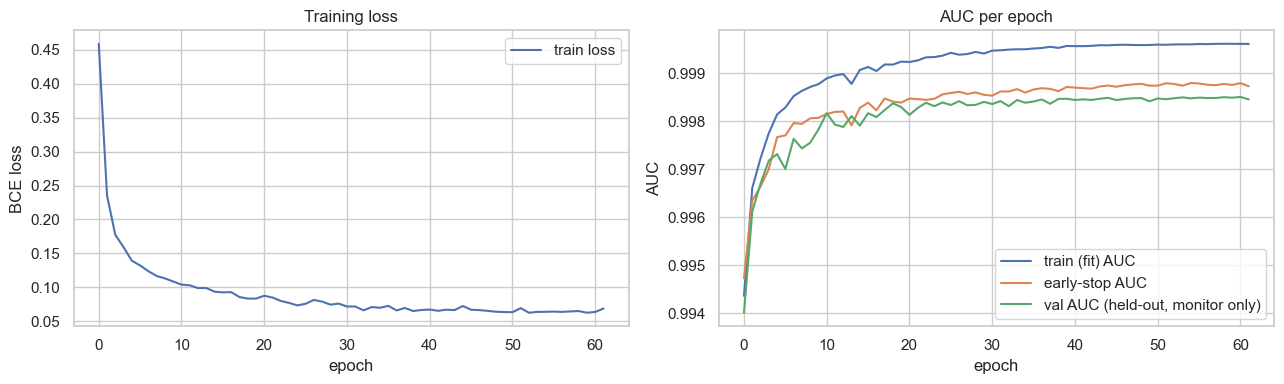

In [35]:
# Train the MLP on the Part-2 train fold and evaluate on the held-out validation fold.
t0 = time.time()
mlp_model, mlp_history = train_mlp(X_train_proc, y_train, X_val_proc, y_val, DEVICE)
print(f"Training time: {time.time() - t0:.1f}s")

train_auc = roc_auc_score(y_train, predict_proba(mlp_model, X_train_proc, DEVICE))
val_auc = roc_auc_score(y_val, predict_proba(mlp_model, X_val_proc, DEVICE))
print(f"Train AUC: {train_auc:.4f} | Validation AUC: {val_auc:.4f} | gap: {train_auc - val_auc:.4f}")

# Learning curves: loss (left) and AUC (right) per epoch.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(mlp_history["train_loss"], label="train loss")
ax1.set_title("Training loss"); ax1.set_xlabel("epoch"); ax1.set_ylabel("BCE loss"); ax1.legend()
ax2.plot(mlp_history["fit_auc"], label="train (fit) AUC")
ax2.plot(mlp_history["earlystop_auc"], label="early-stop AUC")
ax2.plot(mlp_history["val_auc"], label="val AUC (held-out, monitor only)")
ax2.set_title("AUC per epoch"); ax2.set_xlabel("epoch"); ax2.set_ylabel("AUC"); ax2.legend()
plt.tight_layout(); plt.show()

**Train vs. validation (overfitting check).** The two AUC curves track each other closely and the
train-minus-validation gap is small, so the MLP is **not materially overfitting**. The
regularisation built into the model is what keeps the gap small: **Dropout(0.3)** and **weight
decay** limit the effective capacity, while **early stopping** (driven by an internal split of the *training* data, not by the held-out
validation set) halts training once that internal score stops improving, so the over-trained late
epochs are never kept. Because the held-out validation set is never used to choose the model, the
Validation AUC above is an honest estimate. If the gap were to widen, the levers would be stronger dropout / weight decay, a smaller network, or more
training data.

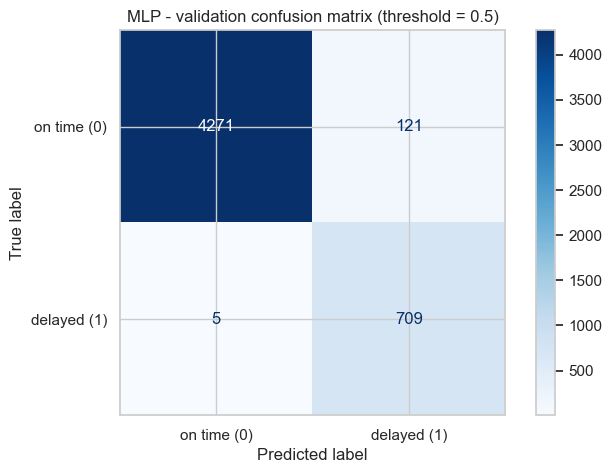

[[4271  121]
 [   5  709]]


In [36]:
# Confusion matrix on the validation set. AUC is threshold-free, but a confusion
# matrix needs a hard decision, so we threshold the probabilities at 0.5.
val_proba = predict_proba(mlp_model, X_val_proc, DEVICE)
val_pred = (val_proba >= 0.5).astype(int)

cm = confusion_matrix(y_val, val_pred)
ConfusionMatrixDisplay(cm, display_labels=["on time (0)", "delayed (1)"]).plot(
    cmap="Blues", values_format="d")
plt.title("MLP - validation confusion matrix (threshold = 0.5)")
plt.show()
print(cm)

**Reading the confusion matrix.** Rows are the true class, columns the predicted class:

- **TN** (top-left): on-time transfers correctly predicted on time.
- **FP** (top-right): on-time transfers wrongly flagged as delayed - a *false alarm* that wastes operational attention.
- **FN** (bottom-left): delayed transfers the model **missed** - operationally the most costly error, since the organisation gets no warning.
- **TP** (bottom-right): delayed transfers correctly caught.

Because the `pos_weight` term makes the model take the minority (delayed) class seriously, the
0.5-threshold operating point favours recall on the delayed class (fewer FN at the cost of more
FP). For the actual scoring metric (**AUC**) the threshold is irrelevant - AUC integrates over
*all* thresholds - so this matrix is shown for interpretability rather than as the final score.

### K-Fold Cross-Validation & ROC (Part 4)

A single train/validation split gives one AUC estimate; **Stratified 5-Fold CV** tells us how
*stable* that estimate is. To avoid leakage, the **Part-2 preprocessor is re-fitted inside every
fold** on that fold's training rows only (the `TargetEncoder` and `StandardScaler` both learn from
the data), and `pos_weight` is recomputed per fold. Early stopping inside each fold uses an internal split of
that fold's training data only, so the fold's test rows are scored but never used to select the
model. Each fold's ROC curve is drawn on shared axes.

/opt/miniconda3/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Fold 1: AUC = 0.9989


/opt/miniconda3/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Fold 2: AUC = 0.9985


/opt/miniconda3/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Fold 3: AUC = 0.9987


/opt/miniconda3/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Fold 4: AUC = 0.9987


/opt/miniconda3/lib/python3.12/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


Fold 5: AUC = 0.9978


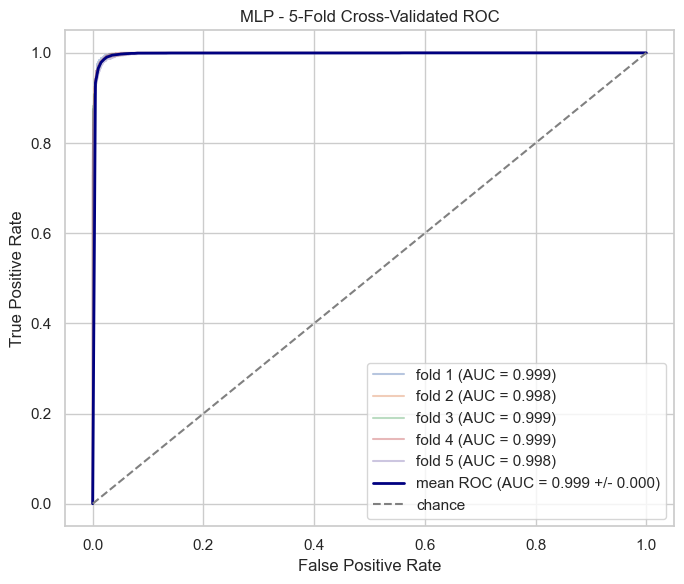


CV AUC: 0.9985 +/- 0.0004


In [37]:
# Stratified 5-fold CV on the raw training data, re-fitting the full preprocessing
# pipeline inside each fold to prevent leakage.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_raw_idx = X_raw.reset_index(drop=True)
y_idx = y.reset_index(drop=True)

mean_fpr = np.linspace(0, 1, 200)
tprs, fold_aucs = [], []

plt.figure(figsize=(7, 6))
for fold, (tr_idx, va_idx) in enumerate(skf.split(X_raw_idx, y_idx), start=1):
    # Engineer + preprocess, fitting only on this fold's training rows.
    Xtr = engineer_features(X_raw_idx.iloc[tr_idx])
    Xva = engineer_features(X_raw_idx.iloc[va_idx])
    ytr, yva = y_idx.iloc[tr_idx], y_idx.iloc[va_idx]

    pre = build_preprocessor(IMPUTE_METHOD)
    Xtr_p = pre.fit_transform(Xtr, ytr)
    Xva_p = pre.transform(Xva)

    model_k, _ = train_mlp(Xtr_p, ytr, Xva_p, yva, DEVICE, seed=RANDOM_STATE + fold, verbose=False)
    proba_k = predict_proba(model_k, Xva_p, DEVICE)

    auc_k = roc_auc_score(yva, proba_k)
    fold_aucs.append(auc_k)
    fpr, tpr, _ = roc_curve(yva, proba_k)
    interp_tpr = np.interp(mean_fpr, fpr, tpr); interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    plt.plot(fpr, tpr, alpha=0.4, label=f"fold {fold} (AUC = {auc_k:.3f})")
    print(f"Fold {fold}: AUC = {auc_k:.4f}")

mean_tpr = np.mean(tprs, axis=0); mean_tpr[-1] = 1.0
mean_auc, std_auc = np.mean(fold_aucs), np.std(fold_aucs)
plt.plot(mean_fpr, mean_tpr, color="navy", lw=2,
         label=f"mean ROC (AUC = {mean_auc:.3f} +/- {std_auc:.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey", label="chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("MLP - 5-Fold Cross-Validated ROC"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

print(f"\nCV AUC: {mean_auc:.4f} +/- {std_auc:.4f}")

**Cross-validation result.** The five folds give very similar AUCs (small standard deviation), and
the mean ROC sits well above the chance diagonal, so the MLP's performance is **stable across
different splits** and not an artefact of the particular validation fold chosen earlier. The mean
CV AUC is the most trustworthy single-number estimate of how the model will generalise to unseen
transfers.

## Part 5: Test-set Prediction

Finally we apply the **identical** Part-2 preprocessing (`preprocess_test`, using the preprocessor
already fitted on the training fold) to the raw test CSV and write the submission file of predicted
probabilities. The format matches `docs/assignment/submission_example.csv` (`transfer_id,predict_prob`).

In [38]:
# Part 5: predictions on the test set, written in the required submission format.
GROUP_NUMBER = "XX"  # TODO: replace with your actual group number before submitting.

if TEST_PATH.exists():
    test_id, X_test_proc = preprocess_test(TEST_PATH, preprocessor)
    test_proba = predict_proba(mlp_model, X_test_proc, DEVICE)

    submission = pd.DataFrame({"transfer_id": test_id.values,
                               "predict_prob": np.round(test_proba, 4)})
    out_path = f"Submission_group_{GROUP_NUMBER}.csv"
    submission.to_csv(out_path, index=False)
    print(f"Wrote {len(submission)} predictions to {out_path}")
    print(submission.head())
else:
    print(f"'{TEST_PATH}' not found - run this cell once the test file is provided "
          "to produce the submission CSV.")

'data/regional_logistics_transfers_test.csv' not found - run this cell once the test file is provided to produce the submission CSV.
